# E-Commerce Fraud Detection — End-to-End ML Workflow
## Dataset: Kaggle E-Commerce Fraud Detection Dataset
---
> এই notebook-এ একটি real-world dataset ব্যবহার করে সম্পূর্ণ ML Pipeline implement করা হয়েছে।
> প্রতিটি step বাংলায় explain করা হয়েছে এবং code-এ easy English comment দেওয়া হয়েছে।
> Google Colab এবং Local IDE উভয়তেই চলবে।

**Dataset Link:** https://www.kaggle.com/datasets/umuttuygurr/e-commerce-fraud-detection-dataset


---
## Step 1: Data Loading ও First Look

**Google Colab-এ:** প্রথম cell uncomment করে run করো।
**Local IDE-তে:** দ্বিতীয় cell run করো — `Transactions-Dataset.csv` notebook-এর পাশে রাখো।

In [34]:
# ──────────────────────────────────────────────
# SECTION 1: Core data manipulation libraries
# ──────────────────────────────────────────────
import numpy as np       # NumPy: used for numerical operations and array handling
import pandas as pd      # Pandas: used for loading and manipulating tabular data (DataFrames)
import matplotlib.pyplot as plt  # Matplotlib: used to draw charts and plots
import seaborn as sns    # Seaborn: built on top of Matplotlib; makes statistical plots look nicer

# ──────────────────────────────────────────────
# SECTION 2: Scikit-learn — model building tools
# ──────────────────────────────────────────────

# train_test_split  → splits dataset into training set and test set
# cross_val_score   → evaluates model performance using k-fold cross-validation
from sklearn.model_selection import train_test_split, cross_val_score

# StandardScaler   → scales numerical features to have mean=0 and std=1
# OneHotEncoder    → converts categorical text columns into binary (0/1) columns
# LabelEncoder     → converts category labels into integer numbers (e.g., "cat"→0, "dog"→1)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# ColumnTransformer → applies different preprocessing steps to different columns simultaneously
from sklearn.compose import ColumnTransformer

# Pipeline → chains multiple steps (preprocessing + model) into one single object
from sklearn.pipeline import Pipeline

# LogisticRegression → a classification algorithm used to predict binary outcomes (0 or 1)
from sklearn.linear_model import LogisticRegression

# accuracy_score        → calculates what % of predictions were correct
# classification_report → shows precision, recall, f1-score for each class
# confusion_matrix      → shows a table of correct vs incorrect predictions
# ConfusionMatrixDisplay→ renders the confusion matrix as a visual plot
# roc_auc_score         → measures how well the model separates two classes (0 to 1 scale)
# roc_curve             → returns the data points needed to draw the ROC curve plot
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

# ──────────────────────────────────────────────
# SECTION 3: Utility settings
# ──────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")  # Suppresses all warning messages so output stays clean

plt.style.use("default")   # Resets Matplotlib to its default white background style
sns.set(font_scale=1.1)    # Makes all text in Seaborn plots 10% larger for easier reading

print("All libraries imported!")  # Confirms that all imports ran without errors

All libraries imported!


> 📝 **এই code-এ কী হচ্ছে:** সব library import করা হয়েছে। `warnings.filterwarnings('ignore')` অপ্রয়োজনীয় warning বন্ধ রাখে।

In [2]:
# Now we load the dataset — works in both Google Colab and local IDE
# import os

try:
    # Google Colab path — shows a file picker to upload the file
    import google.colab
    from google.colab import files

    print("Running on Google Colab. Please upload titanic.csv")
    uploaded = files.upload()
    CSV_FILE = list(uploaded.keys())[0]

except ImportError:
    # Local IDE path — reads from the same folder as this notebook
    import os

    CSV_FILE = "Transactions-Dataset.csv"
    if not os.path.exists(CSV_FILE):
        raise FileNotFoundError("Place titanic.csv in the same folder as this notebook.")
    print(f"Running locally — loading: {CSV_FILE}")

# Tries to import google.colab — if it succeeds, we're on Colab, so it shows a file upload
# dialog and stores the uploaded filename in CSV_FILE.
# If the import fails (ImportError), we're running locally, so it looks for
# "Transactions-Dataset.csv" in the current folder. If the file isn't there, it crashes
# with a clear error message, so you know exactly what's missing.

# Now we load the dataset
dataframe = pd.read_csv(CSV_FILE)

# Reads the CSV file (whichever path was set above) into a Pandas DataFrame.

print("Dataset loaded!")
print(f"Rows: {len(dataframe):,}")
print(f"Columns: {dataframe.shape[1]}")

# Confirms the file loaded successfully and prints the total number of rows
# (with comma formatting for large numbers) and the total number of columns.

Running locally — loading: Transactions-Dataset.csv
Dataset loaded!
Rows: 299,695
Columns: 17


> 📝 **এই code-এ কী হচ্ছে:** CSV file load করা হয়েছে। `:,` formatting দিলে বড় সংখ্যায় comma আসে — পড়তে সহজ।

---
## Step 2: Dataset বোঝা

### এই Dataset কোথা থেকে এসেছে?
Kaggle-এর E-Commerce Fraud Detection Dataset। Real-world e-commerce transaction-এর pattern follow করে তৈরি synthetic dataset।

### কী সমস্যা solve হবে?
> **Fraud Detection** — একটি online transaction fraud কিনা predict করা।
> Bank বা e-commerce platform চায় fraud transaction আগেই ধরতে — customer ক্ষতিগ্রস্ত হওয়ার আগে।

### প্রতিটি Column-এর মানে

| Column | মানে | Type |
|---|---|---|
| `transaction_id` | Transaction-এর unique ID | ID (drop করব) |
| `user_id` | User-এর ID | ID (drop করব) |
| `account_age_days` | Account কত দিন পুরনো | Numeric |
| `total_transactions_user` | User-এর মোট transaction count | Numeric |
| `avg_amount_user` | User-এর গড় transaction amount | Numeric |
| `amount` | এই transaction-এর amount (USD) | Numeric |
| `country` | Transaction হওয়া দেশ | Categorical |
| `bin_country` | Card-এর BIN দেশ | Categorical |
| `channel` | Web নাকি App | Categorical |
| `merchant_category` | Merchant-এর ধরন | Categorical |
| `promo_used` | Promo use হয়েছে কিনা (0/1) | Binary |
| `avs_match` | Address verification match (0/1) | Binary |
| `cvv_result` | CVV সঠিক কিনা (0/1) | Binary |
| `three_ds_flag` | 3D Secure authentication (0/1) | Binary |
| `transaction_time` | Transaction timestamp | DateTime |
| `shipping_distance_km` | Shipping distance | Numeric |
| **`is_fraud`** | **Target: 1=Fraud, 0=Not Fraud** | **Target** |

### Task কী?
> **Binary Classification** — প্রতিটি transaction fraud (1) নাকি legitimate (0)।

### আমরা কী Achieve করতে চাই?
> এমন ML model যেটা নতুন transaction দেখে fraud কিনা বলতে পারবে।
> Model-টি যেন False Negative (fraud miss) কম করে — fraud miss হওয়া সবচেয়ে বিপজ্জনক।

### আমরা কী Achieve করতে পারব?
> Dataset-এ মাত্র **~2.2% fraud** — highly imbalanced।
> Accuracy দিয়ে judge করলে হবে না — **Recall** ও **F1 Score** বেশি গুরুত্বপূর্ণ।
> Simple Logistic Regression দিয়ে শুরু করে baseline তৈরি করব।

### কীভাবে চিন্তা করতে হবে?
> নতুন account + বড় amount + CVV মেলে না + country mismatch = fraud সন্দেহজনক।
> এই domain knowledge মাথায় রেখে features দেখব এবং engineer করব।
> Imbalanced class handle করতে `class_weight='balanced'` ব্যবহার করব।


In [3]:
# Now we look at the first 10 rows
print("First 10 rows:")
dataframe.head(10)

First 10 rows:


,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0
5,6,1,141,47,147.93,224.82,FR,FR,web,travel,0,1,1,1,2024-01-26T22:05:08Z,289.06,0
6,7,1,141,47,147.93,125.98,FR,FR,app,electronics,0,1,1,1,2024-01-30T00:51:41Z,443.75,0
7,8,1,141,47,147.93,66.95,FR,RO,web,travel,0,1,1,1,2024-02-11T15:33:30Z,1390.59,0
8,9,1,141,47,147.93,261.58,FR,FR,app,grocery,0,0,0,0,2024-02-22T01:29:55Z,110.51,0
9,10,1,141,47,147.93,97.34,FR,FR,web,electronics,0,0,1,1,2024-03-09T11:13:19Z,232.34,0


> 📝 **এই code-এ কী হচ্ছে:** `head(10)` দিয়ে প্রথম ১০টি row দেখা হয়েছে। প্রতিটি column-এ কী ধরনের data আছে সেটার প্রথম ধারণা পাওয়া যাচ্ছে।

In [4]:
# Now we check shape, types, and info
print("Shape:", dataframe.shape)
print()
print("Column data types:")
print(dataframe.dtypes)
print()
dataframe.info()

Shape: (299695, 17)

Column data types:
transaction_id               int64
user_id                      int64
account_age_days             int64
total_transactions_user      int64
avg_amount_user            float64
amount                     float64
country                     object
bin_country                 object
channel                     object
merchant_category           object
promo_used                   int64
avs_match                    int64
cvv_result                   int64
three_ds_flag                int64
transaction_time            object
shipping_distance_km       float64
is_fraud                     int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_da

> 📝 **এই code-এ কী হচ্ছে:** `shape` দেয় (rows, columns)। `dtypes` প্রতিটি column-এর type। `info()` dtype, non-null count এবং memory usage একসাথে দেখায়।

In [5]:
# Now we see statistical summary
print("Statistical summary (numeric columns):")
dataframe.describe().T

Statistical summary (numeric columns):


,count,mean,std,min,25%,50%,75%,max
transaction_id,299695.0,149848.000000,86514.638800,1.00,74924.50,149848.00,224771.50,299695.00
user_id,299695.0,3002.559432,1732.309663,1.00,1501.00,3007.00,4504.00,6000.00
account_age_days,299695.0,973.397871,525.241409,1.00,516.00,975.00,1425.00,1890.00
total_transactions_user,299695.0,50.673321,5.976391,40.00,46.00,51.00,56.00,60.00
avg_amount_user,299695.0,148.142973,200.364624,3.52,46.19,90.13,173.45,4565.29
amount,299695.0,177.165279,306.926507,1.00,42.10,89.99,191.11,16994.74
promo_used,299695.0,0.153640,0.360603,0.00,0.00,0.00,0.00,1.00
avs_match,299695.0,0.837999,0.368453,0.00,1.00,1.00,1.00,1.00
cvv_result,299695.0,0.872110,0.333968,0.00,1.00,1.00,1.00,1.00
three_ds_flag,299695.0,0.784588,0.411109,0.00,1.00,1.00,1.00,1.00


> 📝 **এই code-এ কী হচ্ছে:** `describe().T` transpose করে দেখানো হয়েছে। count, mean, std, min, max, percentile একসাথে — `.T` দিলে column-per-row হয়, পড়তে সহজ।

In [6]:
# Now we check unique value counts
print("Unique values per column:")
dataframe.nunique()

Unique values per column:


transaction_id             299695
user_id                      6000
account_age_days             1801
total_transactions_user        21
avg_amount_user              5347
amount                      60043
country                        10
bin_country                    10
channel                         2
merchant_category               5
promo_used                      2
avs_match                       2
cvv_result                      2
three_ds_flag                   2
transaction_time           297975
shipping_distance_km        73447
is_fraud                        2
dtype: int64

> 📝 **এই code-এ কী হচ্ছে:** `nunique()` প্রতিটি column-এ unique value count দেখায়। `transaction_id` সব unique, `channel` মাত্র ২টি unique।

---
## Step 3: Missing Values Check


In [7]:
# Now we check for missing values in every column
missing_counts = dataframe.isnull().sum()
missing_percent = (dataframe.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percent (%)": missing_percent
})
# isnull().sum() counts how many NaN values exist in each column → stored in missing_counts.
# isnull().mean() gives the fraction of NaN values per column (e.g. 0.3 = 30% missing),
# multiplied by 100 and rounded to 2 decimal places → stored in missing_percent.
# Both Series are combined into a single DataFrame called missing_summary so you can see


print("Missing values per column:")
print(missing_summary)
print()
print(f"Total missing values: {dataframe.isnull().sum().sum()}")
# the count and percentage side by side for every column.
# The final isnull().sum().sum() double-sums across all columns to give one single number —
# the total count of all missing values in the entire dataset.

Missing values per column:
                         Missing Count  Missing Percent (%)
transaction_id                       0                  0.0
user_id                              0                  0.0
account_age_days                     0                  0.0
total_transactions_user              0                  0.0
avg_amount_user                      0                  0.0
amount                               0                  0.0
country                              0                  0.0
bin_country                          0                  0.0
channel                              0                  0.0
merchant_category                    0                  0.0
promo_used                           0                  0.0
avs_match                            0                  0.0
cvv_result                           0                  0.0
three_ds_flag                        0                  0.0
transaction_time                     0                  0.0
shipping_dist

> 📝 **এই code-এ কী হচ্ছে:** `isnull().sum()` NaN count দেয়। `isnull().mean() * 100` percentage দেয়। দুটো একসাথে DataFrame-এ দেখানো হয়েছে।

In [8]:
# Now we check for hidden missing values (zeros that should not be zero)
print("Hidden missing value check:")
print(f"shipping_distance_km = 0: {(dataframe['shipping_distance_km'] == 0).sum()}")
print(f"amount = 0:               {(dataframe['amount'] == 0).sum()}")
print(f"account_age_days = 0:     {(dataframe['account_age_days'] == 0).sum()}")
print()
print("Only 1 row has shipping_distance_km=0 -- likely a real edge case, not missing.")

Hidden missing value check:
shipping_distance_km = 0: 1
amount = 0:               0
account_age_days = 0:     0

Only 1 row has shipping_distance_km=0 -- likely a real edge case, not missing.


> 📝 **এই code-এ কী হচ্ছে:** Hidden missing values check করা হয়েছে। shipping_distance_km=0 মাত্র ১টি row — likely real case।

---
## Step 4: EDA — Distribution ও Outlier

### Columns আলাদা করা


In [9]:
# Now we separate columns into groups for organized analysis

id_columns = ["transaction_id", "user_id"]
target_column = "is_fraud"
datetime_column = "transaction_time"

numeric_feature_columns = [
    "account_age_days", "total_transactions_user", "avg_amount_user",
    "amount", "shipping_distance_km"
]

binary_columns = ["promo_used", "avs_match", "cvv_result", "three_ds_flag"]

categorical_feature_columns = ["country", "bin_country", "channel", "merchant_category"]

print("ID columns:           ", id_columns)
print("Target column:        ", target_column)
print("Datetime column:      ", datetime_column)
print("Numeric columns:      ", numeric_feature_columns)
print("Binary columns:       ", binary_columns)
print("Categorical columns:  ", categorical_feature_columns)

ID columns:            ['transaction_id', 'user_id']
Target column:         is_fraud
Datetime column:       transaction_time
Numeric columns:       ['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'shipping_distance_km']
Binary columns:        ['promo_used', 'avs_match', 'cvv_result', 'three_ds_flag']
Categorical columns:   ['country', 'bin_country', 'channel', 'merchant_category']


> 📝 **এই code-এ কী হচ্ছে:** সব columns-কে type অনুযায়ী ভাগ করা হয়েছে। এই grouping পরের সব steps-এ ব্যবহার হবে।

### Target Variable Distribution


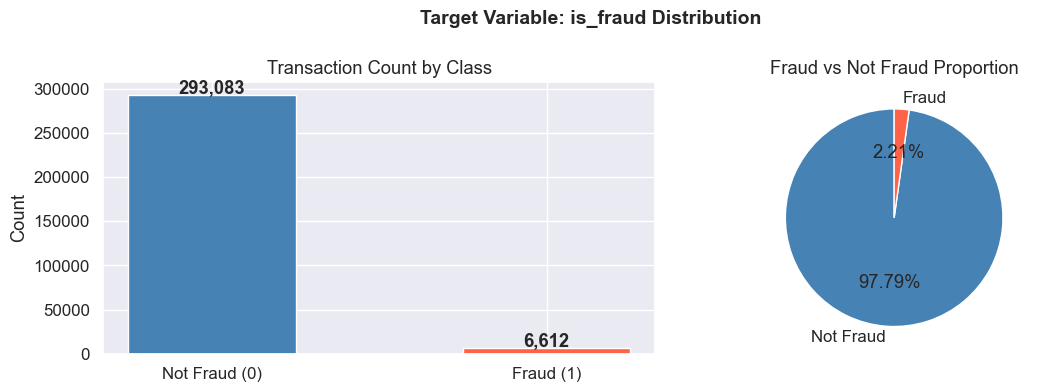

Not Fraud: 293,083 (97.79%)
Fraud:     6,612 (2.21%)

IMPORTANT: ~2.2% fraud -- HIGHLY IMBALANCED dataset!
We must NOT rely on Accuracy alone. Recall and F1 are more important.


In [35]:
# Now we visualize the target variable distribution
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
# Explanation: Creates a canvas with 1 row and 2 columns so we can display
# a Bar Chart and a Pie Chart side-by-side in one single figure.

fraud_counts = dataframe[target_column].value_counts()
# Explanation: Counts how many 0s (Not Fraud) and 1s (Fraud) exist in the target column
# and stores those totals in fraud_counts so both plots can use them.

# Left: count bar chart
axes[0].bar(
    ["Not Fraud (0)", "Fraud (1)"],
    fraud_counts.values,
    color=["steelblue", "tomato"],
    edgecolor="white", width=0.5
)
axes[0].set_title("Transaction Count by Class")
axes[0].set_ylabel("Count")
for index, value in enumerate(fraud_counts.values):
    axes[0].text(index, value + 1000, f"{value:,}", ha="center", fontweight="bold")
# Explanation: Draws a Bar Chart on the left side. Bar heights represent the count of each class.
# The for loop places the exact count as bold text just above each bar, so the values
# are readable without estimating from the y-axis.

# Right: pie chart proportion
axes[1].pie(
    fraud_counts.values,
    labels=["Not Fraud", "Fraud"],
    autopct="%1.2f%%",
    colors=["steelblue", "tomato"],
    startangle=90
)
axes[1].set_title("Fraud vs Not Fraud Proportion")
# Explanation: Draws a Pie Chart on the right side showing each class as a percentage.
# autopct="%1.2f%%" automatically prints the percentage value inside each slice.
# startangle=90 rotates the chart so it starts from the top (12 o'clock position).

plt.suptitle("Target Variable: is_fraud Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: suptitle() adds one bold title centered above both charts.
# tight_layout() automatically adjusts spacing so the two plots don't overlap.
# show() renders and displays the entire figure on screen.

print(f"Not Fraud: {fraud_counts[0]:,} ({fraud_counts[0]/len(dataframe)*100:.2f}%)")
print(f"Fraud:     {fraud_counts[1]:,} ({fraud_counts[1]/len(dataframe)*100:.2f}%)")
print()
print("IMPORTANT: ~2.2% fraud -- HIGHLY IMBALANCED dataset!")
print("We must NOT rely on Accuracy alone. Recall and F1 are more important.")
# Explanation: Prints the exact counts and percentages as text output.
# Also flags a critical problem: since Fraud is only ~2.2% of data, a lazy model could
# score 97.8% accuracy by always predicting "Not Fraud" — which is completely useless.
# This is why Recall and F1-score are the metrics that actually matter here.

> 📝 **এই code-এ কী হচ্ছে:** Target variable-এর distribution দেখানো হয়েছে। Bar chart absolute count, pie chart proportion দেখায়।

> ### এই chart কীভাবে observe করব
> - **Left bar chart**: দুটো class-এর absolute count। Bar-এর উপরে count লেখা।
> - **Right pie chart**: proportion (%) দেখায় — কোন class কতটুকু আছে সহজে বোঝা যায়।

> ### এই chart থেকে কী observe করলাম
> - মোট ২,৯৯,৬৯৫টি transaction-এর মধ্যে মাত্র ৬,৬১২টি fraud মাত্র **২.২%**।
> - বাকি **৯৭.৮%** legitimate transaction।
> - এটা **Highly Imbalanced Dataset** — fraud class অনেক rare।

> ### এই observation থেকে কী decision নেব
> - Accuracy misleading হবে: সব 'Not Fraud' predict করলেও ৯৭.৮% accuracy আসবে!
> - **Recall** ও **F1 Score** দিয়ে evaluate করতে হবে।
> - Model training-এ `class_weight='balanced'` ব্যবহার করব।


### Numeric Features Histogram


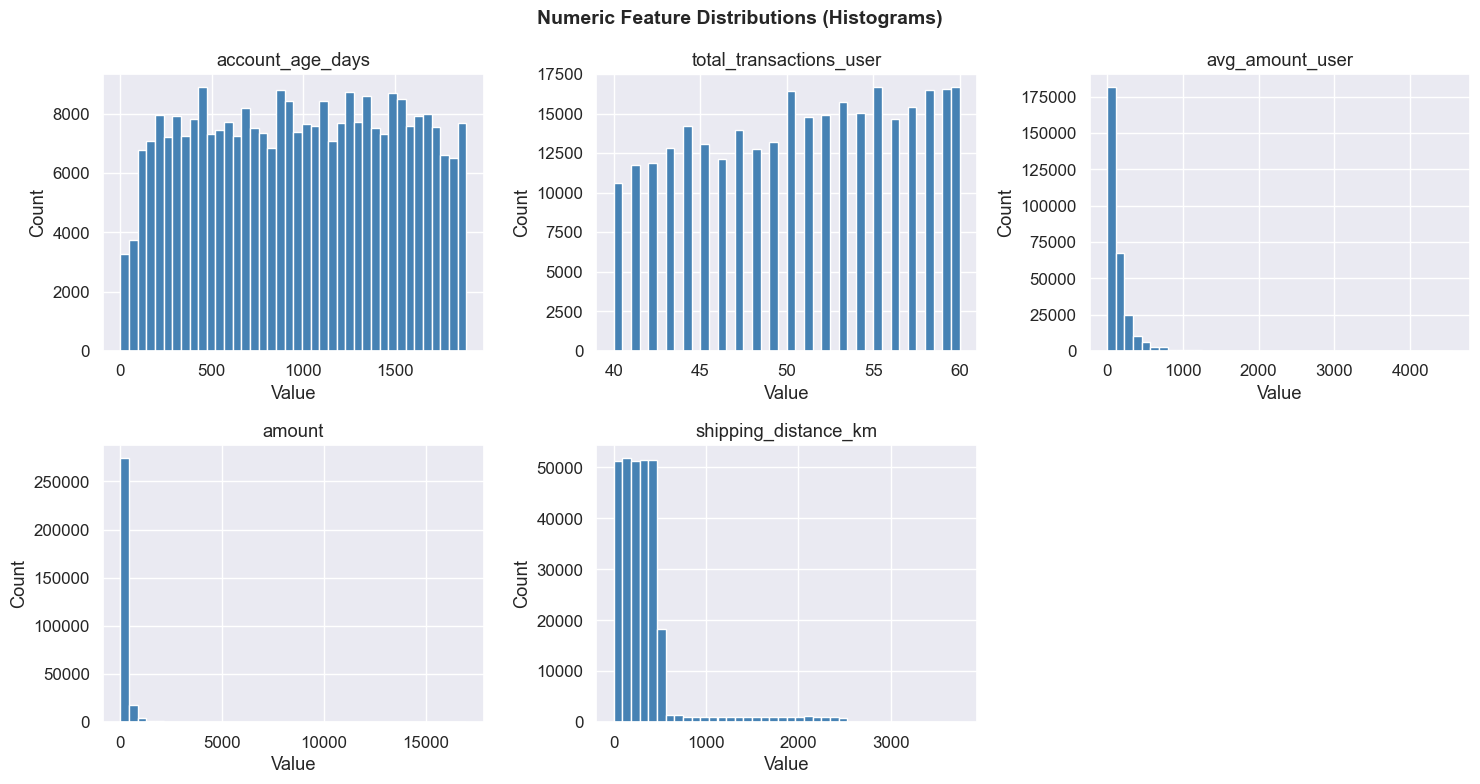

In [11]:
# Now we plot histograms for all numeric features

figure, axes_array = plt.subplots(2, 3, figsize=(15, 8))
axes_array = axes_array.flatten()
# Explanation: We are setting up a grid to show multiple charts at once.
# 'subplots(2, 3)' creates a layout with 2 rows and 3 columns (total 6 spots).
# '.flatten()' converts this 2D grid into a simple 1D list, making it easier to loop through each spot.

for index, column in enumerate(numeric_feature_columns):
    axes_array[index].hist(dataframe[column], bins=40,
                           color="steelblue", edgecolor="white")
    axes_array[index].set_title(column)
    axes_array[index].set_xlabel("Value")
    axes_array[index].set_ylabel("Count")
# Explanation: This is a loop that goes through each numeric column in your list.
# For each column, it draws a histogram in one of the spots on our grid.
# It sets the bars to 'steelblue' color, adds a title with the column name, and labels the axes.

axes_array[-1].set_visible(False)
# Explanation: Since we created 6 spots but might only have 5 numeric columns,
# the last spot would be empty and look like an ugly blank box.
# This line simply hides that last empty spot to keep the final output clean.

plt.suptitle("Numeric Feature Distributions (Histograms)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: Finally, we add a big main title at the top of the whole figure.
# 'tight_layout()' makes sure the charts don't overlap each other, and 'show()' displays everything.

> 📝 **এই code-এ কী হচ্ছে:** সব numeric feature-এর histogram একসাথে দেখানো হয়েছে। `flatten()` দিয়ে 2D subplot array-কে 1D করা হয়েছে।

> ### এই chart কীভাবে observe করব
> - X-axis = feature value, Y-axis = সেই value কতবার আছে।
> - **Bell shape** = normal distribution। **Right tail** = right skewed (অনেক ছোট value, কিছু খুব বড়)।

> ### এই chart থেকে কী observe করলাম
> - `amount`: Right-skewed। বেশিরভাগ transaction ছোট amount, কিছু অনেক বড় (outlier সম্ভব)।
> - `account_age_days`: প্রায় uniform। নতুন থেকে পুরনো সব ধরনের account আছে।
> - `shipping_distance_km`: Right-skewed। বেশিরভাগ কাছে, কিছু অনেক দূরে।
> - `avg_amount_user`: Right-skewed। কিছু user অনেক বড় amount-এ transaction করে।

> ### এই observation থেকে কী decision নেব
> - `amount` ও `shipping_distance_km`-এ outlier check দরকার।


### Numeric Features Boxplot (Outlier)


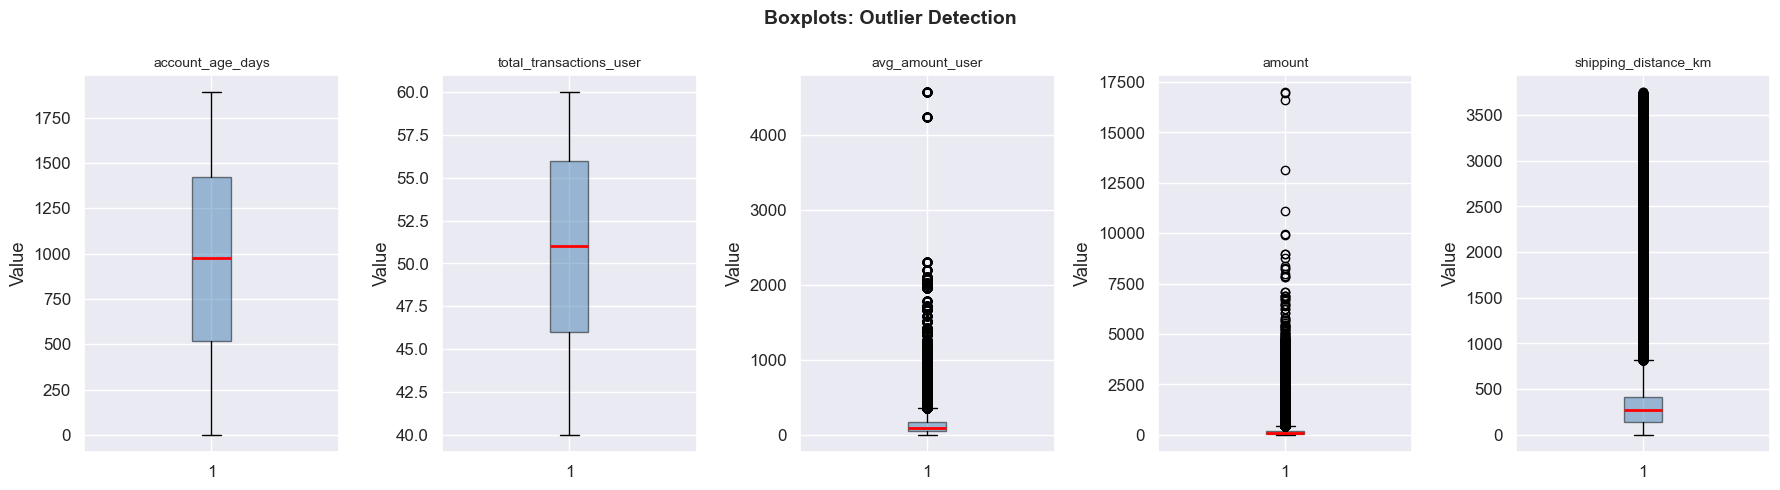

In [37]:
# Now we plot boxplots to detect outliers

figure, axes_array = plt.subplots(1, len(numeric_feature_columns), figsize=(18, 5))
# Explanation: We are creating a row of multiple empty plots side-by-side.
# The number of plots is automatically decided by 'len(numeric_feature_columns)',
# meaning every numeric column gets its own chart. The 'figsize' sets the width and height of the entire row.


for index, column in enumerate(numeric_feature_columns):
    axes_array[index].boxplot(
        dataframe[column],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
        medianprops=dict(color="red", linewidth=2)
    )
    axes_array[index].set_title(column, fontsize=10)
    axes_array[index].set_ylabel("Value")
# Explanation: This loop goes through each numeric column and draws a 'boxplot' in its assigned spot.
# 'patch_artist=True' allows us to fill the box with color. 'boxprops' sets the box color to 'steelblue'
# with some transparency ('alpha'), and 'medianprops' makes the middle line 'red' and thick so it is
# easy to see. This chart helps us see the data spread and find any points (outliers) outside the whiskers.


plt.suptitle("Boxplots: Outlier Detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: 'plt.suptitle' adds a big main title at the very top of all charts.
# 'plt.tight_layout()' is used to automatically adjust the padding so that titles
# and labels from different charts do not overlap. Finally, 'plt.show()' displays the complete visualization.

> 📝 **এই code-এ কী হচ্ছে:** Boxplot দিয়ে outlier দেখানো হয়েছে। Box = Q1 to Q3। Red line = median। Dots outside whisker = outlier।

> ### এই chart কীভাবে observe করব
> - **Box** = Q1 থেকে Q3 (middle 50% data)।
> - **লাল line** = Median।
> - **Whisker (দণ্ড)** = Q1-1.5*IQR থেকে Q3+1.5*IQR।
> - **Dots outside whisker** = Outlier।

> ### এই chart থেকে কী observe করলাম
> - `amount`: অনেক outlier। কিছু transaction অনেক বড় amount-এর।
> - `shipping_distance_km`: Upper end-এ outlier আছে।
> - `avg_amount_user`: Outlier দেখা যাচ্ছে।
> - `account_age_days` ও `total_transactions_user`: তুলনামূলক clean।

> ### এই observation থেকে কী decision নেব
> - `amount`-এ capping করব। Fraud transaction-এ extreme amount real হতে পারে, তাই remove নয়।


### Categorical Features Distribution


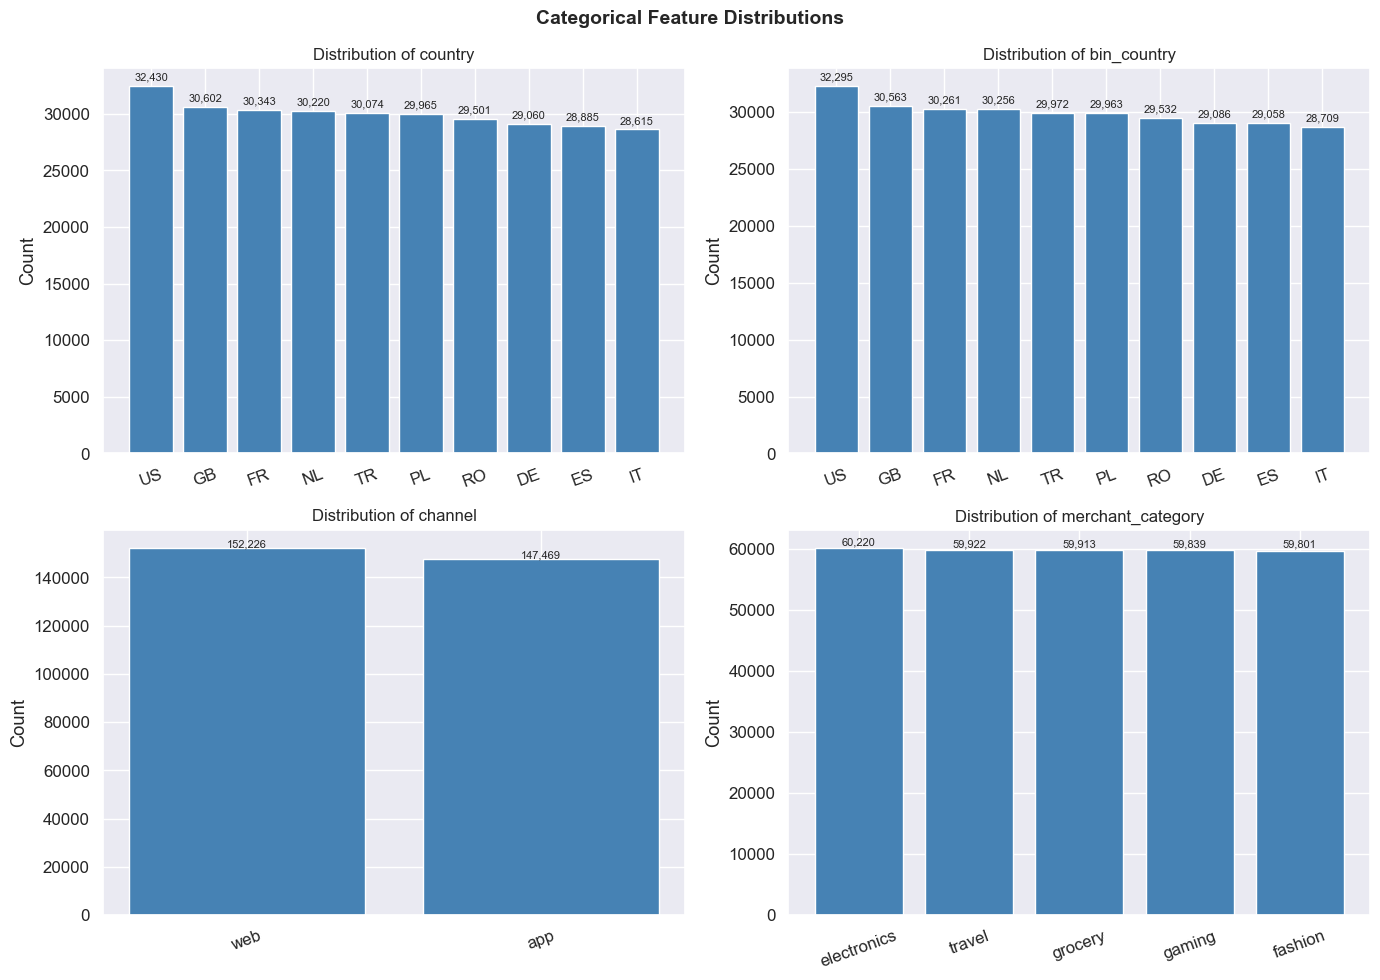

Binary columns distribution:
  promo_used: 0=253,650  1=46,045
  avs_match: 0=48,551  1=251,144
  cvv_result: 0=38,328  1=261,367
  three_ds_flag: 0=64,558  1=235,137


In [38]:
# Now we plot bar charts for categorical features

figure, axes_array = plt.subplots(2, 2, figsize=(14, 10))
axes_array = axes_array.flatten()
# Explanation: We are creating a 'figure' with a 2x2 grid of empty charts.
# Since 'subplots' returns a 2D array, we use 'flatten()' to turn it into a 1D list
# so we can easily loop through each 'axes_array' index from 0 to 3.


for index, column in enumerate(categorical_feature_columns):
    value_counts = dataframe[column].value_counts()
    axes_array[index].bar(value_counts.index, value_counts.values,
                          color="steelblue", edgecolor="white")
    axes_array[index].set_title(f"Distribution of {column}", fontsize=12)
    axes_array[index].set_ylabel("Count")
    axes_array[index].tick_params(axis="x", rotation=20)
    for bar_index, bar_value in enumerate(value_counts.values):
        axes_array[index].text(bar_index, bar_value + 500,
                               f"{bar_value:,}", ha="center", fontsize=8)
# Explanation: This 'for' loop goes through each category in 'categorical_feature_columns'.
# It calculates the 'value_counts' for each category and builds a 'bar' chart.
# We use 'rotation=20' to tilt the labels on the x-axis so they don't overlap.
# The nested 'for' loop uses 'axes_array[index].text' to write the actual count
# numbers on top of each bar so we can see the exact values clearly.


plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: 'plt.suptitle' adds a large main title at the very top of the entire image.
# 'plt.tight_layout()' automatically adjusts the spacing between the charts to prevent
# overlap, and 'plt.show()' displays the final visualization on the screen.


print("Binary columns distribution:")
for column in binary_columns:
    counts = dataframe[column].value_counts()
    print(f"  {column}: 0={counts.get(0,0):,}  1={counts.get(1,0):,}")
# Explanation: This final block focuses on 'binary_columns' (columns with only two values like 0 and 1).
# It loops through the list and uses 'value_counts' to find the total for each class.
# The 'counts.get(0,0)' part ensures that if a category (like 0) is missing, it prints 0
# instead of causing an error.

> 📝 **এই code-এ কী হচ্ছে:** Categorical features-এর bar chart এবং binary columns-এর count print করা হয়েছে।

> ### এই chart কীভাবে observe করব
> - X-axis = category name, Y-axis = সেই category-তে কতটি transaction।
> - Bar-এর উপরে exact count লেখা আছে।

> ### এই chart থেকে কী observe করলাম
> - `country` ও `bin_country`: ১০টি দেশ, বেশ balanced distribution।
> - `channel`: web ও app-এ ভাগ হয়ে আছে।
> - `merchant_category`: ৫টি category, সব roughly equal।

> ### এই observation থেকে কী decision নেব
> - সব categorical column-এ OneHot Encoding করব। কোনো ordinal relationship নেই।


---
## Step 5: Features vs Target সম্পর্ক

### Numeric Features vs is_fraud


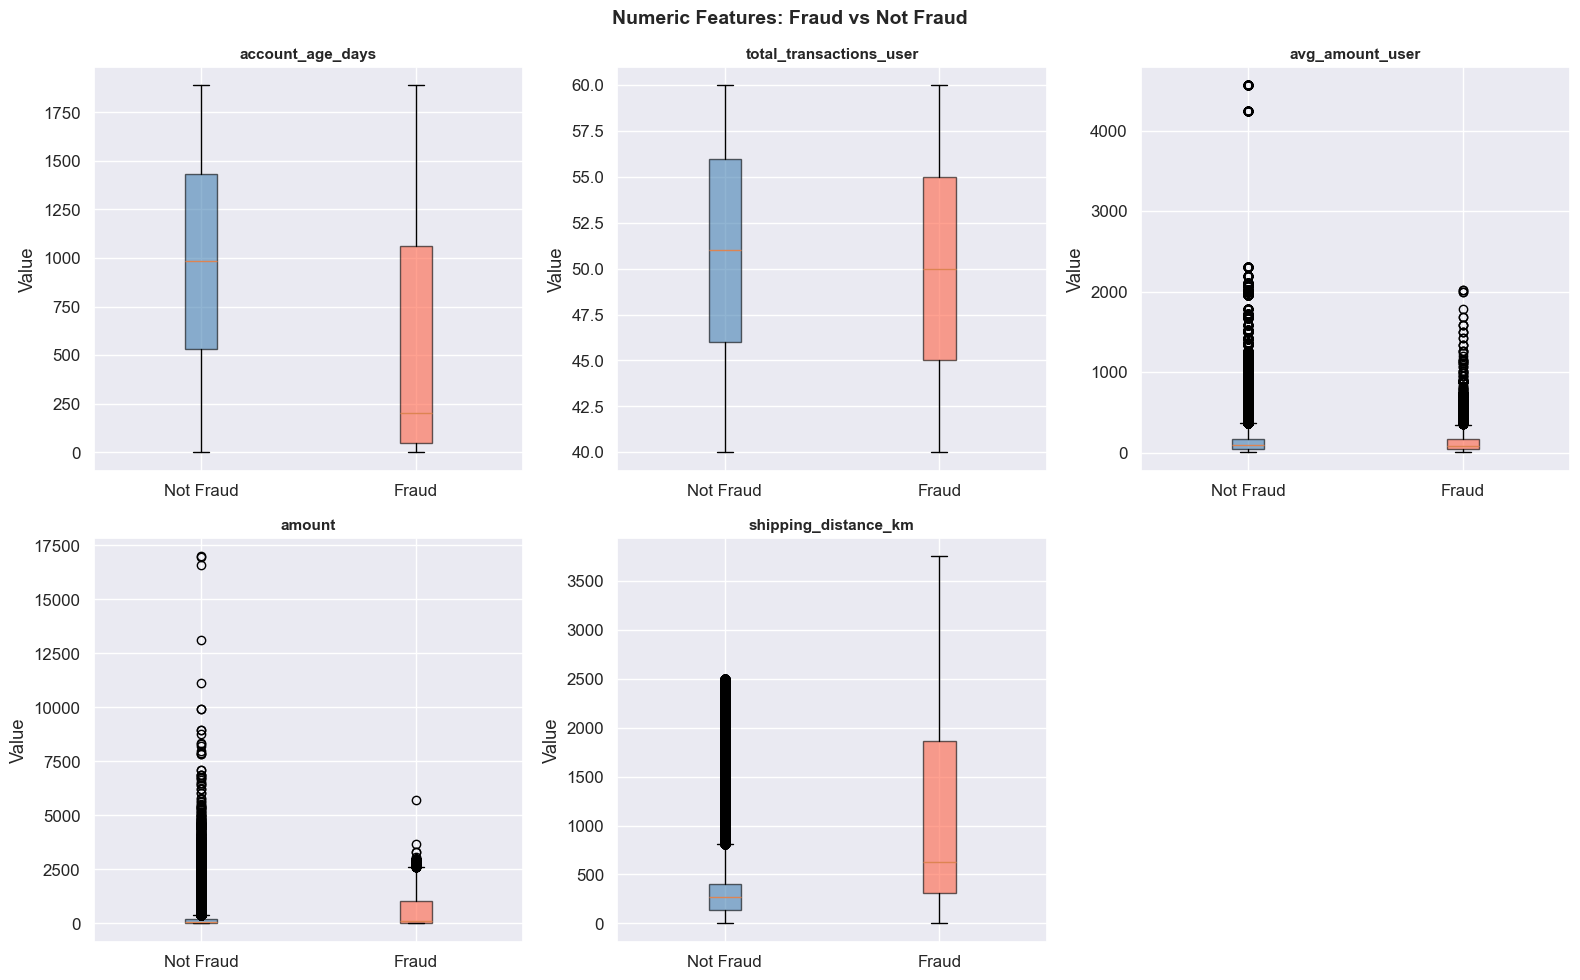

In [39]:
# Now we compare numeric features between fraud and non-fraud

figure, axes_array = plt.subplots(2, 3, figsize=(16, 10))
axes_array = axes_array.flatten()
# Explanation: We are setting up a grid of 6 empty plots (2 rows and 3 columns) using 'subplots'.
# We then use 'flatten()' to convert the grid from a 2D matrix into a simple 1D list so we can
# easily loop through each 'axes_array' index from 0 to 5.


for index, column in enumerate(numeric_feature_columns):
    not_fraud_values = dataframe[dataframe[target_column] == 0][column]
    fraud_values = dataframe[dataframe[target_column] == 1][column]

    box_plot = axes_array[index].boxplot(
        [not_fraud_values, fraud_values],
        labels=["Not Fraud", "Fraud"],
        patch_artist=True
    )
# Explanation: This 'for' loop goes through each numeric feature. For each feature, we split
# the data into two groups: 'not_fraud_values' (where the target is 0) and 'fraud_values'
# (where the target is 1). Then, we draw a 'boxplot' comparing these two side-by-side on
# the same chart to see if there is any visible difference in their distribution.


    box_plot["boxes"][0].set_facecolor("steelblue")
    box_plot["boxes"][0].set_alpha(0.6)
    box_plot["boxes"][1].set_facecolor("tomato")
    box_plot["boxes"][1].set_alpha(0.6)

    axes_array[index].set_title(column, fontsize=11, fontweight="bold")
    axes_array[index].set_ylabel("Value")
# Explanation: This block focuses on the design. We access 'box_plot["boxes"]' to change the
# colors manually. The first box (Not Fraud) is set to 'steelblue' and the second box (Fraud)
# is set to 'tomato' (reddish). We also set 'alpha' to 0.6 to make the colors slightly transparent.
# Finally, we add a bold 'set_title' using the column name.


axes_array[-1].set_visible(False)
# Explanation: Since our grid has 6 spots, but we might only have 5 numeric columns to plot,
# the 6th chart would be empty. We use 'set_visible(False)' on the last index to hide that
# empty white box, making the final figure look much cleaner.


plt.suptitle("Numeric Features: Fraud vs Not Fraud", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: 'plt.suptitle' adds the main heading at the very top. 'plt.tight_layout()'
# automatically fixes the spacing so that titles and labels do not overlap between the
# different charts. Finally, 'plt.show()' renders the entire visual on your screen.

> 📝 **এই code-এ কী হচ্ছে:** প্রতিটি numeric feature-এর distribution fraud (লাল) ও not-fraud (নীল) আলাদা করে দেখানো হয়েছে।

> ### এই chart কীভাবে observe করব
> - প্রতিটি subplot-এ দুটো boxplot: **নীল = Not Fraud, লাল = Fraud**।
> - দুটো box আলাদা position-এ থাকলে সেই feature fraud predict করতে useful।
> - দুটো box একই জায়গায় থাকলে সেই feature কম useful।

> ### এই chart থেকে কী observe করলাম
> - `account_age_days`: Fraud-এ account তুলনামূলক নতুন। Clear pattern!
> - `amount`: Fraud transaction-এ amount কিছুটা বেশি।
> - `avg_amount_user`: Fraud-এ user-এর গড় amount বেশি।
> - `shipping_distance_km`: Fraud-এ distance বেশি হওয়ার pattern দেখা যায়।

> ### এই observation থেকে কী decision নেব
> - `account_age_days` ও `amount` strong predictors। Domain feature engineering-এ কাজে লাগবে।


### Categorical Features vs is_fraud


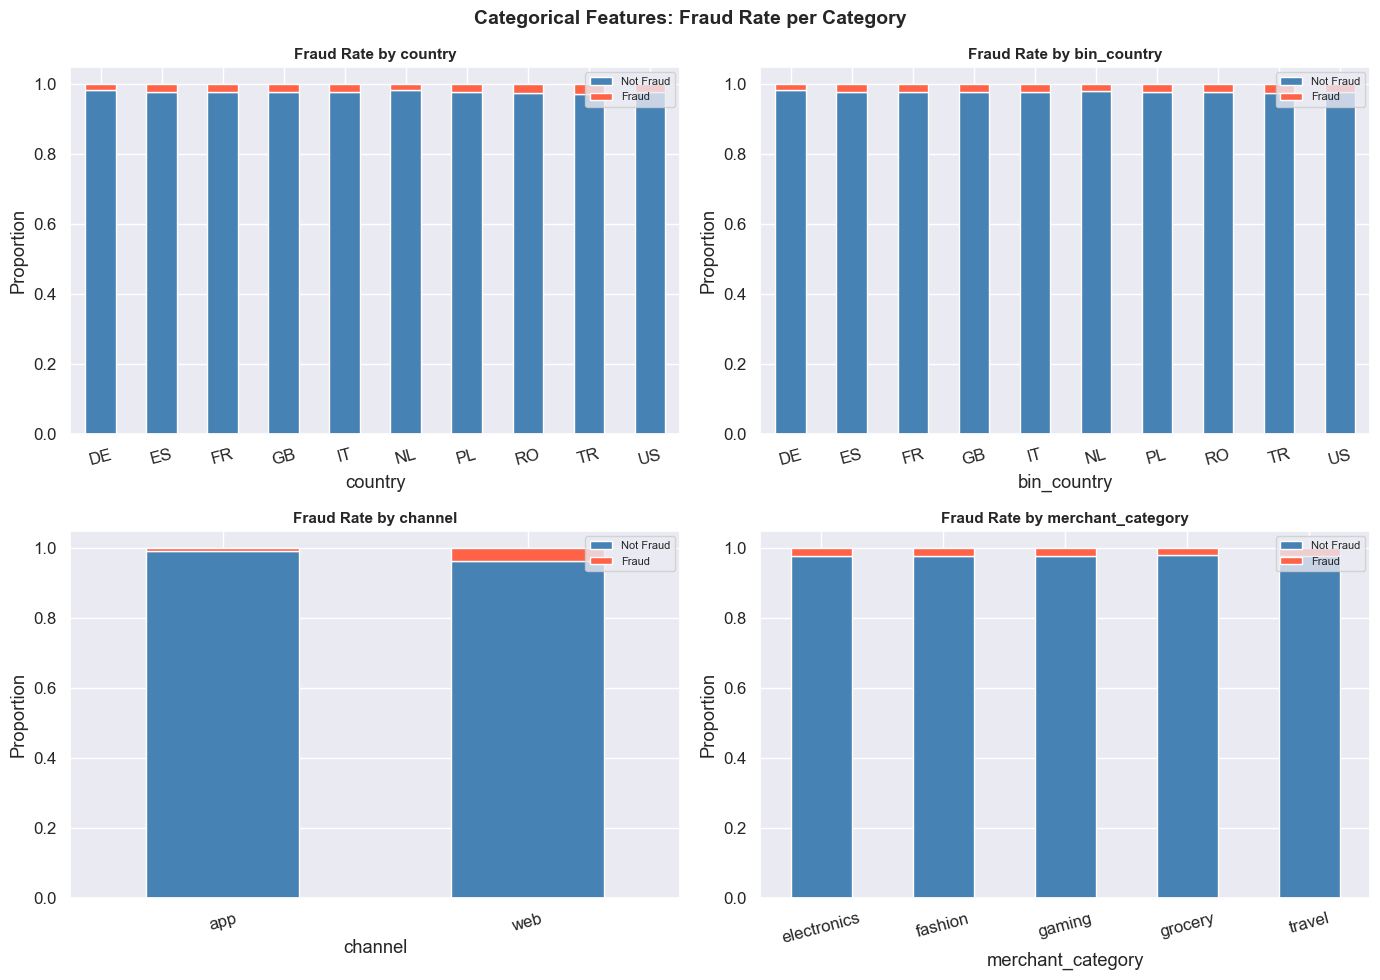

Exact Fraud Rates per Category:

country:
country
TR    0.0280
RO    0.0240
PL    0.0234
ES    0.0231
US    0.0231
FR    0.0219
IT    0.0212
GB    0.0212
NL    0.0178
DE    0.0167

bin_country:
bin_country
TR    0.0261
PL    0.0233
RO    0.0230
ES    0.0229
IT    0.0223
US    0.0220
GB    0.0218
FR    0.0216
NL    0.0196
DE    0.0180

channel:
channel
web    0.0356
app    0.0080

merchant_category:
merchant_category
travel         0.0232
electronics    0.0225
fashion        0.0224
gaming         0.0216
grocery        0.0206


In [40]:
# Now we show fraud rate per category

figure, axes_array = plt.subplots(2, 2, figsize=(14, 10))
axes_array = axes_array.flatten()
# Explanation: We are creating a layout of 4 charts (2 rows and 2 columns) using 'subplots'.
# We use 'flatten()' to convert the grid into a 1D list so we can loop through the 'axes_array'
# using a single index from 0 to 3.


for index, column in enumerate(categorical_feature_columns):
    cross_table = pd.crosstab(
        dataframe[column], dataframe[target_column], normalize="index"
    )
    cross_table.columns = ["Not Fraud", "Fraud"]

    cross_table.plot(
        kind="bar", stacked=True, ax=axes_array[index],
        color=["steelblue", "tomato"], edgecolor="white"
    )
# Explanation: For each category, we use 'pd.crosstab' to create a frequency table between the feature
# and the target. The 'normalize="index"' part is very important—it converts raw counts into
# percentages (0 to 1) so we can see the relative 'Fraud' rate. We then use '.plot' with 'stacked=True'
# to draw a bar where 'Not Fraud' and 'Fraud' are stacked on top of each other.


    axes_array[index].set_title(f"Fraud Rate by {column}", fontsize=11, fontweight="bold")
    axes_array[index].set_ylabel("Proportion")
    axes_array[index].tick_params(axis="x", rotation=15)
    axes_array[index].legend(loc="upper right", fontsize=8)
# Explanation: Here we are styling each individual subplot. We set a bold 'set_title' for each chart,
# label the y-axis as 'Proportion', and use 'rotation=15' to make the x-axis labels readable.
# The 'legend' is placed at the top-right to show which color represents which class.


plt.suptitle("Categorical Features: Fraud Rate per Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: 'plt.suptitle' adds the main header for the entire visualization.
# 'plt.tight_layout()' ensures that the subplots have enough space and don't overlap,
# and 'plt.show()' finally renders the charts on the screen.


print("Exact Fraud Rates per Category:")
for column in categorical_feature_columns:
    print(f"\n{column}:")
    fraud_rate = dataframe.groupby(column)[target_column].mean().sort_values(ascending=False)
    print(fraud_rate.round(4).to_string())
# Explanation: This final block prints the mathematical data behind the charts.
# We use 'groupby' on each column and calculate the 'mean' of the 'target_column'.
# Since the target is 0 and 1, the mean represents the percentage of 1s (fraud rate).
# We use 'sort_values' to show the categories with the highest fraud risk at the top.

> 📝 **এই code-এ কী হচ্ছে:** Stacked bar chart দিয়ে প্রতিটি category-তে fraud proportion দেখানো হয়েছে। লাল অংশ = fraud proportion।

> ### এই chart কীভাবে observe করব
> - প্রতিটি bar = একটি category। **লাল অংশ = fraud proportion।**
> - সব bar-এ লাল অংশ সমান মানে সেই feature fraud-এর সাথে সম্পর্কিত নয়।
> - বার আলাদা height-এর লাল অংশ = feature useful।

> ### এই chart থেকে কী observe করলাম
> - `country` ও `bin_country`-এ fraud rate কিছুটা ভিন্ন দেশ-ভেদে।
> - `merchant_category`-এ ভিন্নতা দেখা যেতে পারে।

> ### এই observation থেকে কী decision নেব
> - Country mismatch (transaction country শ্রেষ্ঠ card BIN country) একটি important domain feature হবে।


### Correlation Heatmap


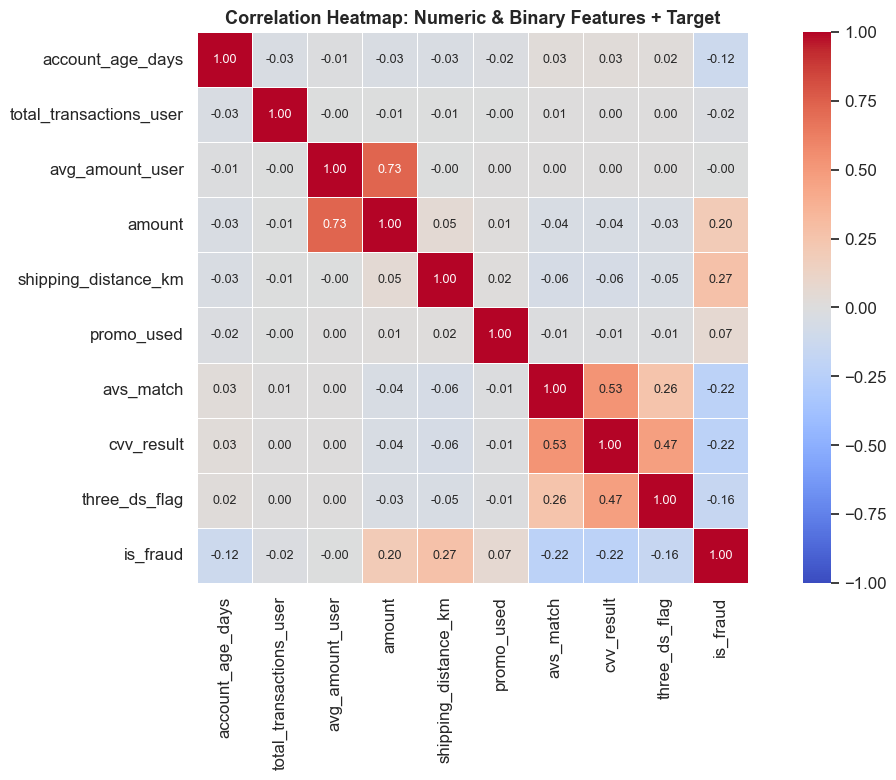

Feature correlations with is_fraud (sorted):
is_fraud                   1.0000
shipping_distance_km       0.2700
amount                     0.2025
promo_used                 0.0674
avg_amount_user           -0.0012
total_transactions_user   -0.0171
account_age_days          -0.1203
three_ds_flag             -0.1622
cvv_result                -0.2190
avs_match                 -0.2233


In [41]:
# Now we compute and plot the correlation heatmap

correlation_columns = numeric_feature_columns + binary_columns + [target_column]
correlation_matrix = dataframe[correlation_columns].corr()
# Explanation: First, we combine all our numeric features, binary features, and the 'target_column' into one list.
# Then, we calculate the 'correlation_matrix' using the '.corr()' method. This tells us how much
# each feature is mathematically related to others (from -1 to 1).


plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True,
    annot_kws={"size": 9}
)
# Explanation: We are using 'sns.heatmap' to visualize the correlation. 'annot=True' writes the actual
# numbers inside each box, and 'cmap="coolwarm"' sets the color (red for positive, blue for negative).
# We set 'vmin=-1' and 'vmax=1' to ensure the color scale is balanced. 'linewidths=0.5' adds a small
# gap between the squares to make the map look cleaner.


plt.title("Correlation Heatmap: Numeric & Binary Features + Target",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: Here we add a bold 'title' to the plot. 'plt.tight_layout()' ensures that the axis labels
# (feature names) are not cut off at the edges, and 'plt.show()' displays the final heatmap on the screen.


print("Feature correlations with is_fraud (sorted):")
target_correlations = correlation_matrix[target_column].sort_values(ascending=False)
print(target_correlations.round(4).to_string())
# Explanation: This final block focuses only on our target variable. We take the 'target_column'
# from the matrix and use '.sort_values(ascending=False)' to list features from the most positive
# correlation to the least. This helps us quickly identify which features have the strongest
# relationship with fraud.

> 📝 **এই code-এ কী হচ্ছে:** Pearson correlation matrix heatmap। Target column-এর সাথে সব feature-এর correlation sorted।

> ### এই chart কীভাবে observe করব
> - **গাঢ় লাল** = strong positive correlation (+1 দিকে)।
> - **গাঢ় নীল** = strong negative correlation (-1 দিকে)।
> - **সাদা** = correlation নেই।
> - **Diagonal সবসময় 1** — নিজের সাথে নিজের correlation।
> - `is_fraud` row/column-এ বড় মানের feature বেশি predictive।

> ### এই chart থেকে কী observe করলাম
> - `avs_match`, `cvv_result`, `three_ds_flag` fraud-এর সাথে negative correlation।
>   মানে: security check fail = fraud বেশি। এগুলো strong predictors!
> - `amount` fraud-এর সাথে সামান্য positive। বড় amount = fraud বেশি।
> - Feature-feature high correlation নেই। Multicollinearity সমস্যা নেই।

> ### এই observation থেকে কী decision নেব
> - `avs_match`, `cvv_result`, `three_ds_flag` গুরুত্বপূর্ণ feature।
> - security_failure_score নামে এগুলো combine করে একটি domain feature বানাব।


---
## Step 6: Feature Engineering ও Train/Test Split

### Feature Engineering — Timestamp থেকে


In [44]:
# Now we extract time-based features from the transaction_time column
# and create domain features BEFORE splitting

dataframe_engineered = dataframe.copy()
# Explanation: We are creating a duplicate of our original dataset called 'dataframe_engineered'.
# This is a safe practice to ensure that any changes we make during feature engineering
# do not accidentally modify or mess up the original 'dataframe'.


# Parse datetime column
dataframe_engineered["transaction_time"] = pd.to_datetime(
    dataframe_engineered["transaction_time"]
)
# Explanation: Raw date and time are usually loaded as simple text (strings).
# We use 'pd.to_datetime' to convert the 'transaction_time' column into a special
# datetime object. This allows Python to understand years, months, hours, and minutes
# so we can perform calculations on them.


# Here we extract hour, day of week, and night flag
dataframe_engineered["transaction_hour"] = dataframe_engineered["transaction_time"].dt.hour
dataframe_engineered["transaction_day_of_week"] = dataframe_engineered["transaction_time"].dt.dayofweek
dataframe_engineered["transaction_is_night"] = (
    (dataframe_engineered["transaction_hour"] >= 22) |
    (dataframe_engineered["transaction_hour"] <= 5)
).astype(int)
# Explanation: This is the feature extraction part. We use '.dt.hour' to get the clock hour (0-23)
# and '.dt.dayofweek' to get the day (Monday=0, Sunday=6). We also create a custom binary feature
# called 'transaction_is_night'. It checks if a transaction happened between 10 PM (22) and 5 AM.
# Finally, '.astype(int)' converts the True/False result into 1 and 0 so the model can read it.


print("Datetime features extracted!")
print(dataframe_engineered[["transaction_time", "transaction_hour", "transaction_day_of_week", "transaction_is_night"]].head(8))
# Explanation: After the hard work, we print a confirmation message. We then use '.head(8)'
# to display the first 8 rows of our new features side-by-side. This helps us manually
# verify that the hours and the night flag were calculated correctly from the original time.

Datetime features extracted!
           transaction_time  transaction_hour  transaction_day_of_week  \
0 2024-01-06 04:09:39+00:00                 4                        5   
1 2024-01-09 20:13:47+00:00                20                        1   
2 2024-01-12 06:20:11+00:00                 6                        4   
3 2024-01-15 17:00:04+00:00                17                        0   
4 2024-01-17 01:27:31+00:00                 1                        2   
5 2024-01-26 22:05:08+00:00                22                        4   
6 2024-01-30 00:51:41+00:00                 0                        1   
7 2024-02-11 15:33:30+00:00                15                        6   

   transaction_is_night  
0                     1  
1                     0  
2                     0  
3                     0  
4                     1  
5                     1  
6                     1  
7                     0  


> 📝 **এই code-এ কী হচ্ছে:** Timestamp column থেকে hour, day of week, এবং night flag extract করা হয়েছে। রাতে (22:00-05:00) transaction হলে `transaction_is_night = 1` — fraud বেশি হওয়ার pattern হতে পারে।

In [46]:
# Now we create 4 domain-driven features based on fraud domain knowledge

# Feature 1: Country mismatch -- card country is different from transaction country
dataframe_engineered["country_mismatch"] = (
    dataframe_engineered["country"] != dataframe_engineered["bin_country"]
).astype(int)
# Explanation: We are creating 'country_mismatch' to detect potential fraud. It checks if the
# transaction 'country' is different from the card's origin country ('bin_country').
# If they don't match, it returns True, which '.astype(int)' converts to a 1; otherwise, it's 0.


# Feature 2: Amount compared to user's average -- how unusual is this transaction?
dataframe_engineered["amount_to_avg_ratio"] = (
    dataframe_engineered["amount"] / (dataframe_engineered["avg_amount_user"] + 1)
)
# Explanation: We are calculating how the current 'amount' relates to the user's normal spending.
# By dividing 'amount' by 'avg_amount_user', we get a ratio. We add '+ 1' to the denominator
# to prevent a "division by zero" error. A high ratio means this transaction is unusually large for this user.


# Feature 3: New account making a very large transaction -- high risk combination
amount_75th_percentile = dataframe_engineered["amount"].quantile(0.75)
dataframe_engineered["new_account_large_amount"] = (
    (dataframe_engineered["account_age_days"] < 30) &
    (dataframe_engineered["amount"] > amount_75th_percentile)
).astype(int)
# Explanation: This feature identifies high-risk behavior. First, we find the top 25% highest
# transaction values using 'quantile(0.75)'. Then, we check if the 'account_age_days' is
# less than 30 AND the 'amount' is in that top tier. If both are true, it's marked as 1.


# Feature 4: Security failure score -- count of failed security checks (0 to 3)
dataframe_engineered["security_failure_score"] = (
    (1 - dataframe_engineered["avs_match"]) +
    (1 - dataframe_engineered["cvv_result"]) +
    (1 - dataframe_engineered["three_ds_flag"])
)
# Explanation: We are aggregating multiple security flags into one 'security_failure_score'.
# Since 1 means success and 0 means failure in the original columns, '1 - value' flips them.
# By adding them up, a score of 3 means the user failed AVS, CVV, and 3D-Secure checks—a huge red flag.


print("Domain features created!")
print()

print("Sample of new features:")
print(dataframe_engineered[["country_mismatch", "amount_to_avg_ratio", "new_account_large_amount", "security_failure_score", "is_fraud"]].head(10))
# Explanation: This simply prints the first 10 rows of our newly created features along with
# the 'is_fraud' target. This is for a quick manual sanity check to see if the values look reasonable.


print("Fraud rate WITH country mismatch:")
print(dataframe_engineered.groupby("country_mismatch")["is_fraud"].mean().round(4))
print()

print("Fraud rate WITH new_account_large_amount:")
print(dataframe_engineered.groupby("new_account_large_amount")["is_fraud"].mean().round(4))
# Explanation: Finally, we use 'groupby' to see if our new features actually correlate with fraud.
# By calculating the 'mean' of 'is_fraud', we see the actual percentage of fraudulent transactions
# for each condition. If the rate is much higher for '1' than '0', the feature is working well.

Domain features created!

Sample of new features:
   country_mismatch  amount_to_avg_ratio  new_account_large_amount  \
0                 0             0.569059                         0   
1                 0             0.724501                         0   
2                 0             0.620157                         0   
3                 0             0.755187                         0   
4                 1             0.892433                         0   
5                 0             1.509568                         0   
6                 0             0.845901                         0   
7                 1             0.449540                         0   
8                 0             1.756396                         0   
9                 0             0.653596                         0   

   security_failure_score  is_fraud  
0                       0         0  
1                       3         0  
2                       0         0  
3                       0  

> 📝 **এই code-এ কী হচ্ছে:** ৪টি domain feature তৈরি করা হয়েছে। country_mismatch: card দেশ শ্রেষ্ঠ transaction দেশ হলে সন্দেহজনক। amount_to_avg_ratio: এই transaction user-এর গড়ের তুলনায় কতগুণ বেশি। new_account_large_amount: নতুন account + বড় amount = high risk combination। security_failure_score: কতটি security check fail হয়েছে (0 থেকে 3)।

> ### নতুন domain features-এর validation
> উপরের print output দেখো:
> - country_mismatch=1 group-এ fraud rate বেশি হলে feature useful।
> - new_account_large_amount=1 group-এ fraud rate বেশি হলে feature useful।
> - এই validation দেখিয়ে দেয় domain knowledge কাজ করছে।


In [19]:
# Now we drop ID columns and raw datetime column
# They have no predictive value for the model

columns_to_drop = [
    "transaction_id",   # unique ID -- no predictive value
    "user_id",          # user ID -- no predictive value
    "transaction_time", # features already extracted from this
]

dataframe_final = dataframe_engineered.drop(columns=columns_to_drop)

print("Columns after dropping:")
print(dataframe_final.columns.tolist())
print()

print("Final shape:", dataframe_final.shape)
print()

print("Showing first 5 rows of final dataframe:")
dataframe_final.head(5)

Columns after dropping:
['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'country', 'bin_country', 'channel', 'merchant_category', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'is_fraud', 'transaction_hour', 'transaction_day_of_week', 'transaction_is_night', 'country_mismatch', 'amount_to_avg_ratio', 'new_account_large_amount', 'security_failure_score']

Final shape: (299695, 21)

Showing first 5 rows of final dataframe:


,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,...,three_ds_flag,shipping_distance_km,is_fraud,transaction_hour,transaction_day_of_week,transaction_is_night,country_mismatch,amount_to_avg_ratio,new_account_large_amount,security_failure_score
0,141,47,147.93,84.75,FR,FR,web,travel,0,1,...,1,370.95,0,4,5,1,0,0.569059,0,0
1,141,47,147.93,107.90,FR,FR,web,travel,0,0,...,0,149.62,0,20,1,0,0,0.724501,0,3
2,141,47,147.93,92.36,FR,FR,app,travel,1,1,...,1,164.08,0,6,4,0,0,0.620157,0,0
3,141,47,147.93,112.47,FR,FR,web,fashion,0,1,...,1,397.40,0,17,0,0,0,0.755187,0,0
4,141,47,147.93,132.91,FR,US,web,electronics,0,1,...,1,935.28,0,1,2,1,1,0.892433,0,0


> 📝 **এই code-এ কী হচ্ছে:** ID columns ও raw datetime drop করা হয়েছে। Datetime থেকে useful features আগেই extract হয়েছে। পরিবর্তন: ৩টি column কমেছে, ৭টি নতুন feature যোগ হয়েছে।

### Train/Test Split


In [47]:
# Now we split into features and target, then train/test split

target_column = "is_fraud"

X_all_features = dataframe_final.drop(columns=[target_column])
y_target = dataframe_final[target_column]

print("Feature matrix shape:", X_all_features.shape)
print("Target vector shape: ", y_target.shape)
# Explanation: We are separating the data into two parts. 'X_all_features' contains all the input
# information (independent variables) by using '.drop()' to remove the target. 'y_target' only
# contains the 'is_fraud' column (the answer key). The 'print' statements confirm the 'shape'
# to ensure the number of rows matches in both.


# 80% train, 20% test
# stratify=y ensures same fraud proportion in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_all_features, y_target,
    test_size=0.20,
    random_state=42,
    stratify=y_target
)
# Explanation: We are using 'train_test_split' to divide the data. 80% goes to training and 20% to
# testing ('test_size=0.20'). 'random_state=42' ensures that the split is exactly the same every
# time we run the code. The 'stratify=y_target' is the most important part here; it ensures
# that the percentage of fraud cases stays the same in both the training and testing sets.


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
# Explanation: After splitting, we check the 'shape' of our new variables. This is quick
# verification to see that the 80/20 division was successful and that we have the expected
# number of samples in 'X_train' and 'X_test'.


print("Fraud rate in train set:", y_train.mean().round(4))
print("Fraud rate in test set: ", y_test.mean().round(4))
print("Both ~2.2% -- stratify=y worked correctly!")
# Explanation: This block calculates the 'mean' of the target in both sets. Since the target is
# 0 and 1, the mean represents the fraud percentage. We are checking if both sets have
# roughly 2.2% fraud. If the numbers match, it proves that 'stratify' worked, and our test set
# is a perfect miniature representation of our training set.

Feature matrix shape: (299695, 20)
Target vector shape:  (299695,)
X_train shape: (239756, 20)
X_test shape:  (59939, 20)
Fraud rate in train set: 0.0221
Fraud rate in test set:  0.0221
Both ~2.2% -- stratify=y worked correctly!


> 📝 **এই code-এ কী হচ্ছে:** `stratify=y_target` দিলে train ও test-এ fraud proportion same থাকে — imbalanced data-তে critical। দুটোতেই ~2.2% fraud দেখা যাবে।

---
## Step 7: Missing Values Handle করা


In [21]:
# Now we verify no missing values exist in final dataset

print("Missing values in final feature matrix (X_train):")
missing_in_train = X_train.isnull().sum()
print(missing_in_train[missing_in_train > 0])
print()

print(f"Total missing in X_train: {X_train.isnull().sum().sum()}")
print()

print("No missing values -- this is a clean synthetic dataset.")
print("In real projects, we add SimpleImputer to the pipeline for missing values.")

Missing values in final feature matrix (X_train):
Series([], dtype: int64)

Total missing in X_train: 0

No missing values -- this is a clean synthetic dataset.
In real projects, we add SimpleImputer to the pipeline for missing values.


> 📝 **এই code-এ কী হচ্ছে:** Final dataset-এ missing values check। এই dataset-এ কোনো missing নেই। Real project-এ এখানে `SimpleImputer` pipeline-এ যোগ করতে হত।

---
## Step 8: Outlier Handle করা


In [48]:
# Now we handle outliers using capping (winsorization)
# We CAP instead of REMOVE because extreme amounts can be real fraud signals.
# Removing them would delete real fraud patterns from our dataset.

columns_to_cap = ["amount", "shipping_distance_km", "avg_amount_user",
                  "amount_to_avg_ratio"]

dataframe_capped = dataframe_final.copy()
# Explanation: We start by defining a list called 'columns_to_cap' which contains the names of the
# features that have extreme values. Then, we create a 'copy()' of our final dataframe.
# This ensures that we don't modify the original data while we are fixing the outliers.


print("Outlier capping using IQR method:")
for column in columns_to_cap:
    Q1 = dataframe_capped[column].quantile(0.25)
    Q3 = dataframe_capped[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
# Explanation: This 'for' loop goes through each column in our list. For each column, we calculate
# 'Q1' (25th percentile) and 'Q3' (75th percentile). We find the 'IQR' (Interquartile Range) by
# subtracting Q1 from Q3. Finally, we set the 'lower_bound' and 'upper_bound' limits.
# Anything outside these limits is mathematically considered an outlier.


    outlier_count = (
        (dataframe_capped[column] < lower_bound) |
        (dataframe_capped[column] > upper_bound)
    ).sum()

    dataframe_capped[column] = dataframe_capped[column].clip(lower_bound, upper_bound)

    print(f"  {column}: {outlier_count} outliers capped "
          f"to range [{lower_bound:.2f}, {upper_bound:.2f}]")
# Explanation: First, we count how many values are outside our bounds and store it in 'outlier_count'.
# Then, we use the '.clip()' method. This is the "capping" part; it forces any value smaller than
# 'lower_bound' to become the lower bound, and any value larger than 'upper_bound' to become
# the upper bound. This keeps the data points but makes them less extreme.


print()
print("After capping -- statistical summary:")
dataframe_capped[columns_to_cap].describe().T
# Explanation: Finally, we print the updated statistical summary using '.describe().T'.
# This allows us to verify that the 'max' and 'min' values of these columns are now
# exactly equal to our calculated bounds. It confirms that the extreme spikes have been
# successfully "tamed" or capped.

Outlier capping using IQR method:
  amount: 26711 outliers capped to range [-181.42, 414.63]
  shipping_distance_km: 20312 outliers capped to range [-272.27, 818.05]
  avg_amount_user: 23890 outliers capped to range [-144.70, 364.34]
  amount_to_avg_ratio: 12529 outliers capped to range [-0.32, 2.41]

After capping -- statistical summary:


,count,mean,std,min,25%,50%,75%,max
amount,299695.0,136.473648,124.075358,1.000000,42.100000,89.990000,191.11000,414.625000
shipping_distance_km,299695.0,294.823741,203.922575,0.000000,136.600000,273.020000,409.18000,818.050000
avg_amount_user,299695.0,125.841739,104.456955,3.520000,46.190000,90.130000,173.45000,364.340000
amount_to_avg_ratio,299695.0,1.095786,0.530156,0.001275,0.700598,0.983362,1.38361,2.408127


> 📝 **এই code-এ কী হচ্ছে:** IQR method দিয়ে outlier detect করে capping করা হয়েছে। Remove করা হয়নি কারণ extreme amount fraud-এর signal হতে পারে। `.clip()` value-কে bound-এর মধ্যে আটকে রাখে।

In [49]:
# Now we re-split after capping
# We redo the split to ensure our processed data is used

X_all_features = dataframe_capped.drop(columns=[target_column])
y_target = dataframe_capped[target_column]
# Explanation: Since we just capped the outliers, we need to refresh our feature matrix and target vector.
# We use '.drop()' to remove the 'target_column' from 'dataframe_capped' and store it in 'X_all_features'.
# The actual answers are stored in 'y_target'. This ensures our model uses the cleaned data.


X_train, X_test, y_train, y_test = train_test_split(
    X_all_features, y_target,
    test_size=0.20,
    random_state=42,
    stratify=y_target
)
# Explanation: We are performing the 'train_test_split' again on our outlier-capped data.
# We keep 'test_size=0.20' for a 20% test set and use 'random_state=42' for consistency.
# The 'stratify=y_target' is reused here to make sure the fraud percentage remains balanced
# in both the new training and testing sets.


print(f"Re-split complete.")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print()
# Explanation: This is a simple confirmation block. We print a message saying the 'Re-split complete'
# and display the 'shape' of our new training and testing matrices. It helps us verify
# that the number of rows and columns are exactly what we expect before moving to training.


print("X_train first 5 rows after outlier capping:")
X_train.head(5)
# Explanation: Finally, we use '.head(5)' to take a quick look at the first few rows of our
# training data. This is a final visual check to see if the values in our capped columns
# (like 'amount') look reasonable and stay within the bounds we calculated earlier.

Re-split complete.
X_train: (239756, 20), X_test: (59939, 20)

X_train first 5 rows after outlier capping:


,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,transaction_hour,transaction_day_of_week,transaction_is_night,country_mismatch,amount_to_avg_ratio,new_account_large_amount,security_failure_score
138086,839,60,141.85,133.14,NL,NL,app,travel,0,1,1,1,386.64,7,6,0,0,0.932027,0,0
6566,876,52,31.12,30.21,NL,NL,app,grocery,0,1,1,1,475.04,10,0,0,0,0.940535,0,0
65697,1674,60,24.24,18.20,GB,GB,web,fashion,0,1,1,0,404.36,7,0,0,0,0.721078,0,1
181023,1551,49,47.81,38.55,FR,FR,web,fashion,0,1,1,1,210.15,9,6,0,0,0.789797,0,0
20468,1676,59,183.39,135.17,IT,IT,app,electronics,1,1,1,1,368.16,3,0,1,0,0.733066,0,0


> 📝 **এই code-এ কী হচ্ছে:** Capping-এর পরে data আবার split করা হয়েছে। DataFrame print করলে দেখা যাবে capped columns-এর max value এখন bound-এর মধ্যে।

---
## Step 9: Feature Engineering (Step 6-এ সম্পন্ন)

Step 6-এ আমরা এই features তৈরি করেছিলাম:

| Feature | কীভাবে তৈরি | কেন useful |
|---|---|---|
| `transaction_hour` | timestamp থেকে hour extract | রাতে fraud বেশি হওয়ার সম্ভাবনা |
| `transaction_day_of_week` | timestamp থেকে weekday | সপ্তাহের কোন দিনে fraud বেশি |
| `transaction_is_night` | hour 22:00-05:00 = 1 | রাতের transaction risk flag |
| `country_mismatch` | transaction country ≠ bin_country | Card দেশ আলাদা হলে সন্দেহজনক |
| `amount_to_avg_ratio` | amount / avg_amount_user | User-এর গড়ের তুলনায় কতগুণ বেশি |
| `new_account_large_amount` | age<30 AND amount>75th percentile | নতুন account + বড় amount = high risk |
| `security_failure_score` | failed_avs + failed_cvv + no_3ds | মোট security check failure count |


---
## Step 10-12: Encoding, Scaling ও sklearn Pipeline

এই তিনটি step একসাথে sklearn Pipeline-এ করব — best practice এটাই।


In [51]:
# Now we define which columns need which treatment

# Numeric columns -- will be StandardScaled
numeric_pipeline_columns = [
    "account_age_days", "total_transactions_user", "avg_amount_user",
    "amount", "shipping_distance_km",
    "transaction_hour", "transaction_day_of_week",
    "amount_to_avg_ratio", "security_failure_score"
]
# Explanation: We are creating a list called 'numeric_pipeline_columns'. These are continuous
# numbers with different scales (e.g., age in days vs transaction amount). We group them
# together because they all need 'StandardScaler' to bring them to a similar range so the
# model can process them fairly.


# Binary and engineered binary columns -- already 0/1, just pass through
binary_passthrough_columns = [
    "promo_used", "avs_match", "cvv_result", "three_ds_flag",
    "transaction_is_night", "country_mismatch", "new_account_large_amount"
]
# Explanation: We are creating a list called 'binary_passthrough_columns'. These columns
# already contain only 0 and 1. Since they are already in a mathematical format the model
# understands, we don't need to change them. We will just "pass them through" the pipeline as they are.


# Categorical columns -- will be OneHot encoded
categorical_pipeline_columns = [
    "country", "bin_country", "channel", "merchant_category"
]
# Explanation: We are grouping text-based features into 'categorical_pipeline_columns'.
# Machine learning models cannot read text like "Retail" or "USA" directly. We group them
# here because they will later need 'OneHotEncoder' to be converted into numeric columns.


print("Numeric (will be scaled):     ", len(numeric_pipeline_columns), "columns")
print("Binary (will pass through):   ", len(binary_passthrough_columns), "columns")
print("Categorical (will be OneHot): ", len(categorical_pipeline_columns), "columns")
print()

print("Total input columns:", len(numeric_pipeline_columns) +
      len(binary_passthrough_columns) + len(categorical_pipeline_columns))
# Explanation: This final block uses the 'len()' function to count how many features we have
# in each group. It then prints the totals and the grand total. This is a crucial check
# to make sure we haven't accidentally missed any columns from our dataframe before
# building the final 'ColumnTransformer'.

Numeric (will be scaled):      9 columns
Binary (will pass through):    7 columns
Categorical (will be OneHot):  4 columns

Total input columns: 20


> 📝 **এই code-এ কী হচ্ছে:** Pipeline-এ কোন column কী treatment পাবে সেটা define করা হয়েছে। Binary columns ইতোমধ্যে 0/1 তাই `passthrough` দিলে unchanged থাকে।

In [52]:
# Now we build the complete preprocessing and model pipeline

# Sub-pipeline for numeric columns: StandardScaler
numeric_sub_pipeline = Pipeline([
    ("standard_scaler", StandardScaler())
])
# Explanation: We are creating a small dedicated 'Pipeline' for numeric data.
# It only has one job: to apply 'StandardScaler', which scales all numbers so they
# have a mean of 0 and a variance of 1. This helps the model converge faster.


# Sub-pipeline for categorical columns: OneHotEncoder
categorical_sub_pipeline = Pipeline([
    ("one_hot_encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
# Explanation: This is another small 'Pipeline' for categorical (text) data.
# It uses 'OneHotEncoder' to turn text categories into 0s and 1s.
# We set 'handle_unknown="ignore"' so that if the test set has a new category
# the model hasn't seen before, it won't crash.


# Combine both sub-pipelines using ColumnTransformer
preprocessing_step = ColumnTransformer([
    ("numeric",     numeric_sub_pipeline,     numeric_pipeline_columns),
    ("categorical", categorical_sub_pipeline, categorical_pipeline_columns),
    ("binary",      "passthrough",            binary_passthrough_columns),
])
# Explanation: Here, we are using 'ColumnTransformer' to act as a traffic controller.
# It sends 'numeric_pipeline_columns' to the numeric pipeline, 'categorical_pipeline_columns'
# to the categorical pipeline, and tells the 'binary_passthrough_columns' to just
# "passthrough" without any changes. This combines everything into one clean processing block.


# Full pipeline: preprocessing + Logistic Regression model
# class_weight="balanced" automatically handles class imbalance
full_pipeline = Pipeline([
    ("preprocessor", preprocessing_step),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=500,
        random_state=42,
        n_jobs=-1
    ))
])
# Explanation: This is the final 'full_pipeline'. It connects the 'preprocessor' we just
# made to the actual 'LogisticRegression' model. By setting 'class_weight="balanced"',
# the model automatically gives more importance to the rare fraud cases (the 2.2% we saw earlier).
# 'n_jobs=-1' tells the computer to use all available CPU cores to speed up the work.


print("Pipeline built successfully!")
print()

print("Pipeline steps:")
for step_name, step_object in full_pipeline.steps:
    print(f"  {step_name} -> {type(step_object).__name__}")
# Explanation: This block confirms everything is ready. It loops through 'full_pipeline.steps'
# and prints each stage. It should show 'preprocessor' first and 'classifier' second.
# This ensures the order of operations is correct: first we clean the data, then we train the model.

Pipeline built successfully!

Pipeline steps:
  preprocessor -> ColumnTransformer
  classifier -> LogisticRegression


> 📝 **এই code-এ কী হচ্ছে:** Complete pipeline তৈরি হয়েছে। `class_weight='balanced'` fraud class-কে automatically বেশি weight দেয়। `n_jobs=-1` সব CPU core ব্যবহার করে দ্রুত চলে।

---
## Step 13: Model Training ও Sanity Check


In [53]:
# Now we train the full pipeline on training data
# One call does: scaling + encoding + model training all at once

print("Training the pipeline...")
full_pipeline.fit(X_train, y_train)
print("Training complete!")
print()
# Explanation: This is the most critical step. We use the '.fit()' method on our 'full_pipeline'.
# In this single step, the pipeline automatically scales the numbers, encodes the categories,
# and then trains the 'LogisticRegression' model using the 'X_train' features and 'y_train' labels.
# It remembers all the transformations so it can apply them exactly the same way later.


# Quick sanity check
y_train_predictions = full_pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_predictions)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print()
# Explanation: Here we are doing a "Sanity Check" to see how well the model learned the training data.
# We use '.predict()' to get the model's guesses for the same data it just studied.
# Then, 'accuracy_score' compares those guesses with the actual 'y_train' answers to give us a
# score. A very high score here usually means the model at least understood the basic patterns.


print("Pipeline ran without errors -- good!")
print("Note: High training accuracy alone does not mean a good model.")
print("We need to check test performance next.")
# Explanation: This is a final reminder printed to the console. It confirms that the code
# finished without crashing. It also warns that 'Training Accuracy' can be misleading
# because of "Overfitting"—the real test of a fraud detection model is how well it handles
# the 'X_test' data, which it has never seen before.

Training the pipeline...
Training complete!

Training Accuracy: 0.8773 (87.73%)

Pipeline ran without errors -- good!
Note: High training accuracy alone does not mean a good model.
We need to check test performance next.


> 📝 **এই code-এ কী হচ্ছে:** `full_pipeline.fit()` একটি call-এ preprocessing ও model training সব হয়ে যায়। Training accuracy দেখা হয়েছে — sanity check যে pipeline কাজ করছে।

---
## Step 14: Model Evaluation


In [54]:
# Now we evaluate on test data -- data the model has never seen before

y_test_predictions = full_pipeline.predict(X_test)
y_test_probabilities = full_pipeline.predict_proba(X_test)[:, 1]
# Explanation: We are finally testing our model on the 'X_test' data.
# We use '.predict()' to get the direct classes (0 or 1).
# We also use '.predict_proba()' to get the raw confidence scores for each transaction.
# The '[:, 1]' part extracts only the probability of being "Fraud" (class 1),
# which is very useful for calculating metrics like the AUC-ROC curve later.


test_accuracy = accuracy_score(y_test, y_test_predictions)

print("=" * 55)
print("MODEL EVALUATION ON TEST DATA")
print("=" * 55)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print()
# Explanation: Here we calculate the 'test_accuracy' by comparing the model's guesses
# with the real answers in 'y_test'. This score tells us how many transactions
# the model labeled correctly overall. We print some decorative equals signs
# to make the output look like a formal report in the console.


print("Classification Report:")
print(classification_report(
    y_test, y_test_predictions,
    target_names=["Not Fraud", "Fraud"]
))
# Explanation: This is the most important part of evaluation.
# Since accuracy can be lying in an imbalanced dataset, we use 'classification_report'.
# It calculates 'Precision', 'Recall', and 'F1-score' for both "Not Fraud" and "Fraud" classes.
# This tells us exactly how many frauds we caught (Recall) and how many times we
# wrongly accused a normal user (Precision).

MODEL EVALUATION ON TEST DATA
Test Accuracy: 0.8783 (87.83%)

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.88      0.93     58617
       Fraud       0.14      0.85      0.23      1322

    accuracy                           0.88     59939
   macro avg       0.57      0.86      0.58     59939
weighted avg       0.98      0.88      0.92     59939



> 📝 **এই code-এ কী হচ্ছে:** Test data-তে model evaluate করা হয়েছে। `predict_proba()[:, 1]` fraud probability দেয় — ROC curve-এ ব্যবহার হবে।

> ### Classification Report কীভাবে পড়ব
> - **Precision (Fraud)**: Model যতগুলো fraud বলেছে তার কতটুকু সত্যিই fraud।
> - **Recall (Fraud)**: সব actual fraud-এর কতটুকু model ধরতে পেরেছে। সবচেয়ে গুরুত্বপূর্ণ!
> - **F1 Score**: Precision ও Recall-এর balance। Imbalanced data-তে accuracy-র চেয়ে ভালো metric।
> - **Support**: সেই class-এ কতটি sample।

> ### কী observe করব
> - Fraud class-এর Recall যত বেশি তত ভালো — বেশি fraud ধরা যাচ্ছে।
> - Not Fraud class-এর Precision বেশি — false alarm কম।


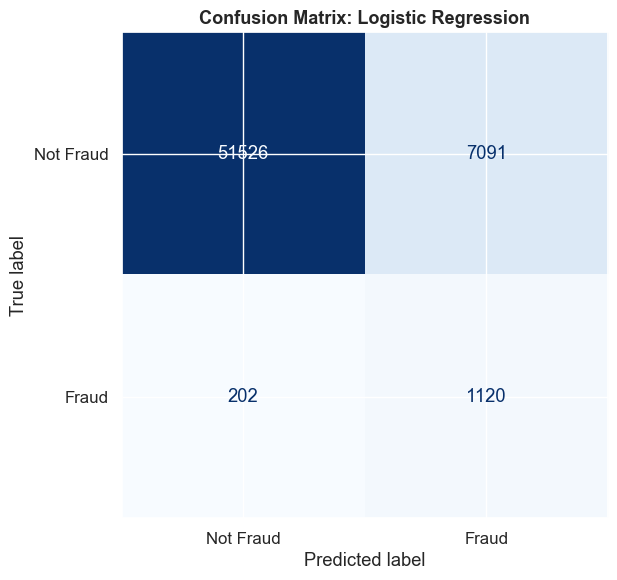

True Negative  (TN): 51,526  -- correctly predicted Not Fraud
False Positive (FP): 7,091  -- predicted Fraud but actually Not Fraud
False Negative (FN): 202  -- predicted Not Fraud but actually FRAUD (dangerous!)
True Positive  (TP): 1,120  -- correctly predicted Fraud

Fraud Recall (catch rate): 84.72%
Fraud Precision:            13.64%


In [55]:
# Now we plot the confusion matrix

confusion_matrix_values = confusion_matrix(y_test, y_test_predictions)
# Explanation: We use the 'confusion_matrix' function to compare the actual values ('y_test')
# with the model's predicted values ('y_test_predictions'). It creates a table of numbers
# that shows exactly where the model was right and where it made mistakes.


figure, axis = plt.subplots(figsize=(7, 6))

confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=["Not Fraud", "Fraud"]
)
# confusion_matrix_display.plot(axis=axis, colorbar=False, cmap="Blues")
confusion_matrix_display.plot(ax=axis, colorbar=False, cmap="Blues")
# Explanation: We are preparing a visual version of the matrix using 'ConfusionMatrixDisplay'.
# The '.plot()' method draws a heatmap-style chart where darker colors represent higher numbers.
# We use 'cmap="Blues"' to make the chart blue and 'ax=axis' to ensure it draws on our
# specified figure size.


plt.title("Confusion Matrix: Logistic Regression", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: These lines add a bold 'title' to the chart, adjust the spacing using
# 'tight_layout' so it looks clean, and finally use 'show()' to display the visual matrix.


TN, FP, FN, TP = confusion_matrix_values.ravel()
print(f"True Negative  (TN): {TN:,}  -- correctly predicted Not Fraud")
print(f"False Positive (FP): {FP:,}  -- predicted Fraud but actually Not Fraud")
print(f"False Negative (FN): {FN:,}  -- predicted Not Fraud but actually FRAUD (dangerous!)")
print(f"True Positive  (TP): {TP:,}  -- correctly predicted Fraud")
print()
# Explanation: We use '.ravel()' to unpack the 2x2 matrix into four individual numbers.
# 'TN' and 'TP' are the model's successes. 'FP' (False Positives) are annoying because they
# block real customers, but 'FN' (False Negatives) are dangerous because they mean
# a fraudster successfully stole money without being caught.


print(f"Fraud Recall (catch rate): {TP/(TP+FN):.2%}")
print(f"Fraud Precision:            {TP/(TP+FP):.2%}")
# Explanation: In this final block, we manually calculate two key metrics using the four numbers
# from above. 'Recall' tells us what percentage of all actual frauds we successfully caught.
# 'Precision' tells us what percentage of our fraud alerts were actually real fraud.

> 📝 **এই code-এ কী হচ্ছে:** Confusion Matrix দেখানো হয়েছে। FN (False Negative) সবচেয়ে বিপজ্জনক — fraud ধরা না গেলে customer ক্ষতিগ্রস্ত।

> ### Confusion Matrix কীভাবে observe করব
> - **Top-left (TN)**: সঠিকভাবে Not Fraud বলেছে।
> - **Top-right (FP)**: ভুলভাবে Fraud বলেছে (false alarm)।
> - **Bottom-left (FN)**: Fraud মিস করেছে। **সবচেয়ে ক্ষতিকর!**
> - **Bottom-right (TP)**: সঠিকভাবে Fraud ধরেছে।

> ### Decision
> FN কম করাই লক্ষ্য। Recall বাড়াতে classification threshold কমানো যায় (default 0.5 থেকে 0.3 এ)।


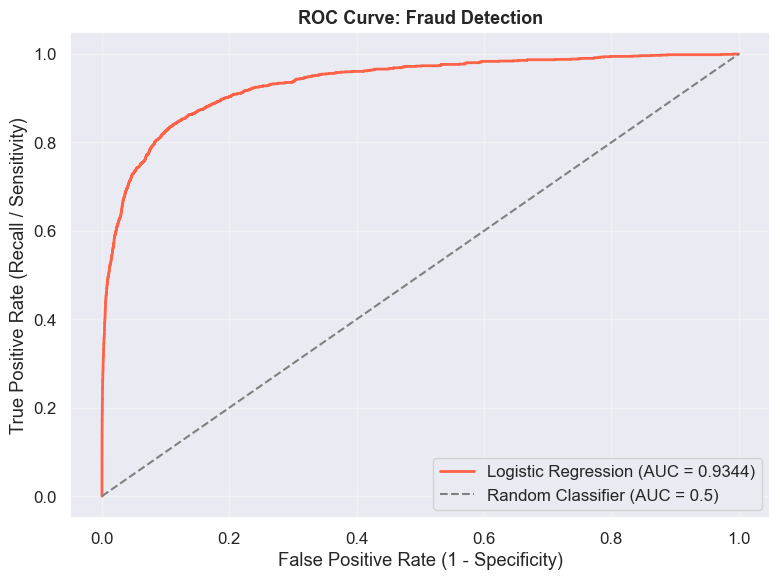

ROC-AUC Score: 0.9344

Good AUC! Model has strong discriminating ability.


In [56]:
# Now we plot the ROC curve

roc_auc = roc_auc_score(y_test, y_test_probabilities)
false_positive_rates, true_positive_rates, thresholds = roc_curve(
    y_test, y_test_probabilities
)
# Explanation: We are calculating the data needed to draw the ROC curve.
# 'roc_auc_score' gives us a single number (AUC) that summarizes the model's overall performance.
# Then, 'roc_curve' calculates the 'false_positive_rates' and 'true_positive_rates' for
# many different threshold levels, which shows how the model balances catching fraud
# versus making false alarms.


plt.figure(figsize=(8, 6))
plt.plot(
    false_positive_rates, true_positive_rates,
    color="tomato", linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier (AUC = 0.5)")
# Explanation: Here we are actually plotting the curve. The 'tomato' colored line represents
# our 'Logistic Regression' model. We also draw a dashed 'gray' line from [0,0] to [1,1]
# which represents a 'Random Classifier' (a model that just guesses). The goal is to
# have our model's curve as far away from this dashed line as possible, towards the top-left corner.


plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall / Sensitivity)")
plt.title("ROC Curve: Fraud Detection", fontsize=13, fontweight="bold")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Explanation: This block adds labels and titles to the graph to make it understandable.
# We add a 'legend' to identify the lines and a light 'grid' to make the coordinates
# easier to read. Finally, 'plt.show()' displays the graph on the screen.


print(f"ROC-AUC Score: {roc_auc:.4f}")
print()
if roc_auc > 0.80:
    print("Good AUC! Model has strong discriminating ability.")
elif roc_auc > 0.70:
    print("Decent AUC. Model shows moderate discriminating ability.")
else:
    print("Low AUC. Model needs improvement.")
# Explanation: This final block prints the actual 'ROC-AUC Score' as a number.
# It then uses an 'if-elif' logic to provide a simple text summary of the result.
# An AUC above 0.80 means the model is very good at "discriminating" or
# telling the difference between a real transaction and a fraud.

> 📝 **এই code-এ কী হচ্ছে:** ROC Curve plot করা হয়েছে। AUC মাপে model কতটা ভালো fraud আলাদা করতে পারছে। 1.0 = perfect, 0.5 = random।

> ### ROC Curve কীভাবে observe করব
> - X-axis = False Positive Rate (ভুলভাবে fraud বলার হার)।
> - Y-axis = True Positive Rate = Recall (সত্যিকার fraud ধরার হার)।
> - **Curve যত উপরে-বামে** = model তত ভালো।
> - **Gray diagonal** = random classifier (coin flip মাত্র)।
> - **AUC** = curve-এর নিচের area। 0.5=random, 1.0=perfect।

> ### Decision
> AUC > 0.75 হলে model কাজ করছে। আরো improve করতে Random Forest বা XGBoost try করা যাবে।


In [59]:
# Now we run 5-fold cross-validation for stability check
# This shows if the model performs consistently on different data splits

print("Running 5-Fold Cross-Validation (may take a few minutes)...")
print()
# Explanation: We print a status message to let the user know that 'cross_validation'
# is starting. Since the model has to be trained and tested 5 different times,
# it informs the user that it might take a little longer than a single training session.


cross_validation_scores = cross_val_score(
    full_pipeline, X_train, y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
# Explanation: This is the core logic. We use 'cross_val_score' to split our 'X_train' data
# into 5 equal parts (folds). The code trains the model on 4 parts and tests it on the
# 1 remaining part, repeating this 5 times. We use 'scoring="roc_auc"' to measure quality
# and 'n_jobs=-1' to use all processor cores for faster calculation.


print("5-Fold Cross-Validation Results (ROC-AUC):")
for fold_number, score in enumerate(cross_validation_scores, 1):
    print(f"  Fold {fold_number}: {score:.4f}")
print()
# Explanation: Here we loop through the 'cross_validation_scores' array generated above.
# We use 'enumerate(..., 1)' to start numbering from 1 and print the individual
# 'ROC-AUC' score for each of the 5 folds. This helps us see if the model failed
# or performed poorly on any specific chunk of data.


print(f"Mean ROC-AUC: {cross_validation_scores.mean():.4f}")
print(f"Std  ROC-AUC: {cross_validation_scores.std():.4f}")
print()
# Explanation: We calculate the 'mean()' to find the average performance across all folds.
# More importantly, we calculate the 'std()' (Standard Deviation). A high standard deviation
# would mean the model's performance is inconsistent, while a low one means it is reliable.


print("Low std means the model is STABLE across different data splits.")
# Explanation: This is a final summary message. It reminds us that if the 'std' (Standard Deviation)
# is close to zero, it proves the model is 'STABLE'. It means the model's success isn't just
# due to "luck" with a specific data split, but it actually understands the general patterns.

Running 5-Fold Cross-Validation (may take a few minutes)...

5-Fold Cross-Validation Results (ROC-AUC):
  Fold 1: 0.9334
  Fold 2: 0.9309
  Fold 3: 0.9339
  Fold 4: 0.9332
  Fold 5: 0.9324

Mean ROC-AUC: 0.9328
Std  ROC-AUC: 0.0010

Low std means the model is STABLE across different data splits.


> 📝 **এই code-এ কী হচ্ছে:** 5-fold cross-validation দিয়ে model-এর stability check। Mean ও Std দেখে বোঝা যাবে model consistent কিনা। Std কম = stable।

Top 15 most important features:
                               Feature  Coefficient
      binary__new_account_large_amount     2.469681
                     binary__avs_match    -1.121487
              categorical__channel_app    -0.975329
                       numeric__amount     0.798353
         numeric__shipping_distance_km     0.797438
                    binary__promo_used     0.682247
       numeric__security_failure_score     0.599124
             numeric__account_age_days    -0.598090
              categorical__channel_web     0.576848
              numeric__avg_amount_user    -0.560543
          numeric__amount_to_avg_ratio    -0.381441
                 binary__three_ds_flag    -0.265139
           categorical__bin_country_DE    -0.203048
              binary__country_mismatch     0.197259
categorical__merchant_category_grocery    -0.169564



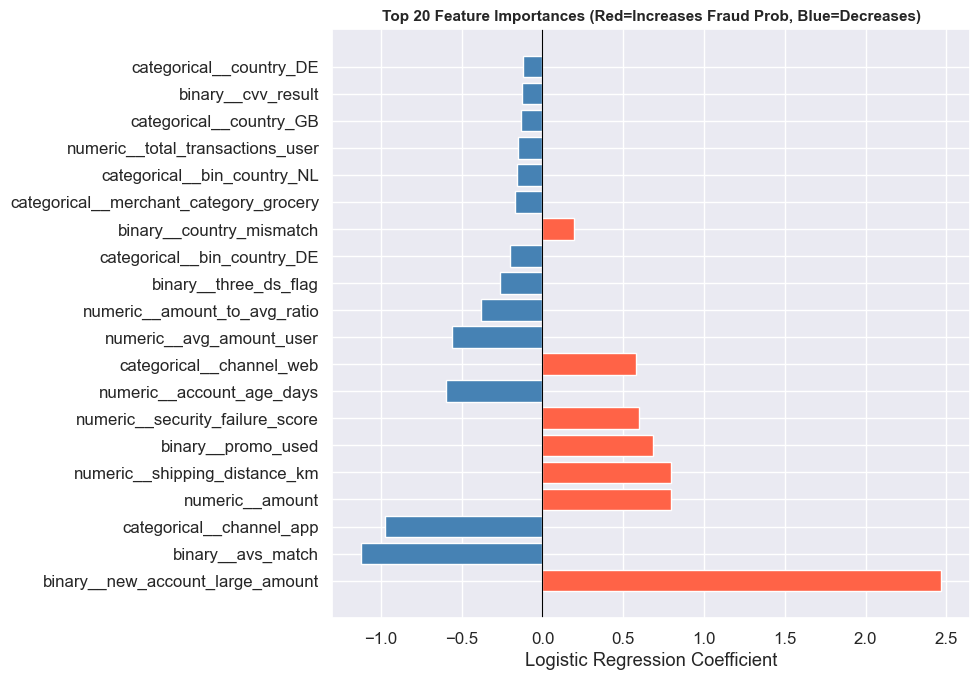

In [60]:
# Now we extract feature importances from Logistic Regression

logistic_regression_model = full_pipeline.named_steps["classifier"]
preprocessor_from_pipeline = full_pipeline.named_steps["preprocessor"]
feature_names_after_encoding = preprocessor_from_pipeline.get_feature_names_out()
# Explanation: We are reaching inside our 'full_pipeline' to grab two main parts: the trained model
# ('classifier') and the 'preprocessor'. Since the preprocessor transformed our columns
# (like creating new columns for categories), we use 'get_feature_names_out()' to get
# the updated list of all final feature names.


feature_importance_dataframe = pd.DataFrame({
    "Feature": feature_names_after_encoding,
    "Coefficient": logistic_regression_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)
# Explanation: We are creating a 'pd.DataFrame' to map each feature name to its mathematical
# 'Coefficient'. In Logistic Regression, a coefficient tells us how much that feature
# influences the result. We use 'sort_values' with 'key=abs' to sort them by their
# overall impact (strength), regardless of whether they are positive or negative.


print("Top 15 most important features:")
print(feature_importance_dataframe.head(15).to_string(index=False))
print()
# Explanation: This block prints the first 15 rows of our importance dataframe.
# It gives us a quick text-based list of which features the model relies on the
# most to detect fraud. Using 'to_string(index=False)' makes the table look
# cleaner in the console by removing the row numbers.


# Plot top 20
top_20_features = feature_importance_dataframe.head(20)
colors = ["tomato" if c > 0 else "steelblue" for c in top_20_features["Coefficient"]]

plt.figure(figsize=(10, 7))
plt.barh(top_20_features["Feature"], top_20_features["Coefficient"],
          color=colors, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
# Explanation: We are creating a horizontal bar chart ('barh') for the top 20 features.
# We use a list comprehension to assign 'tomato' (red) color to positive coefficients
# and 'steelblue' (blue) to negative ones. 'plt.axvline(0)' draws a vertical line
# at zero to clearly separate the positive and negative influences.


plt.xlabel("Logistic Regression Coefficient")
plt.title("Top 20 Feature Importances (Red=Increases Fraud Prob, Blue=Decreases)",
          fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: This final block adds the labels and a bold 'title' to explain the chart.
# Red bars mean that as that feature's value increases, the probability of 'Fraud'
# also increases. Blue bars mean the opposite. 'plt.show()' displays the graph,
# letting us visually identify the biggest "red flags" for fraud.

> 📝 **এই code-এ কী হচ্ছে:** Logistic Regression coefficient দিয়ে feature importance দেখানো হয়েছে। Positive coefficient = fraud probability বাড়ায়। Negative = কমায়। Bar যত লম্বা = তত গুরুত্বপূর্ণ।

> ### Feature Importance chart কীভাবে observe করব
> - **লাল bar (positive coefficient)**: এই feature বেশি হলে fraud probability বাড়ে।
> - **নীল bar (negative coefficient)**: এই feature বেশি হলে fraud probability কমে।
> - **Bar যত লম্বা**: সেই feature তত গুরুত্বপূর্ণ।

> ### কী observe করব
> - Security features (avs_match, cvv_result, three_ds_flag) বড় negative coefficient। এগুলো pass হলে fraud কম।
> - amount_to_avg_ratio positive। User-এর গড়ের চেয়ে অনেক বড় amount = fraud সন্দেহজনক।
> - country_mismatch positive। Card দেশ ও transaction দেশ আলাদা হলে fraud বেশি।


In [61]:
# FINAL SUMMARY REPORT

print("=" * 60)
print("END-TO-END ML WORKFLOW: FINAL SUMMARY")
print("E-Commerce Fraud Detection")
print("=" * 60)
# Explanation: This is just a decorative header. We are using the multiplication operator '*'
# with the string "=" to create a long horizontal line. This makes the final output
# look professional and easy to separate from other logs in the console.


final_roc_auc = roc_auc_score(y_test, y_test_probabilities)
final_accuracy = accuracy_score(y_test, y_test_predictions)
TN_final, FP_final, FN_final, TP_final = confusion_matrix(y_test, y_test_predictions).ravel()
# Explanation: We are gathering all the key performance metrics one last time.
# We calculate the 'roc_auc_score' for overall quality, 'accuracy_score' for general
# correctness, and use '.ravel()' on the 'confusion_matrix' to get the exact counts
# of correct and incorrect predictions.


print("=" * 60)
print("END-TO-END ML WORKFLOW: FINAL SUMMARY")
print("E-Commerce Fraud Detection")
print("=" * 60)
print(f"  Total transactions: {len(dataframe_final):,}")
print(f"  Fraud transactions: {y_target.sum():,} ({y_target.mean():.2%})")
print(f"  Features used:      {X_train.shape[1]}")
# Explanation: This block prints the high-level statistics of the dataset.
# It shows the 'Total transactions' and the actual count of 'Fraud transactions'.
# We also display the number of input 'Features' used, which tells us how complex
# the model's input data was after all the engineering and encoding.


print()
print("FEATURES ENGINEERED:")
print(f"  + transaction_hour            (from timestamp)")
print(f"  + transaction_day_of_week     (from timestamp)")
print(f"  + transaction_is_night        (from timestamp)")
print(f"  + country_mismatch            (domain knowledge)")
print(f"  + amount_to_avg_ratio         (domain knowledge)")
print(f"  + new_account_large_amount    (domain knowledge)")
print(f"  + security_failure_score      (domain knowledge)")
# Explanation: This is a manual summary of the 'engineered' features we created.
# It lists the time-based features and the domain-knowledge features. This part
# is very helpful for explaining the model's logic to a non-technical manager.


print()
print("MODEL: Logistic Regression (class_weight=balanced)")

print()
print("RESULTS:")
print(f"  Test Accuracy:        {final_accuracy:.4f}")
print(f"  ROC-AUC Score:        {final_roc_auc:.4f}")
print(f"  Fraud Recall:         {TP_final/(TP_final+FN_final):.4f} (fraud catch rate)")
print(f"  Fraud Precision:      {TP_final/(TP_final+FP_final):.4f}")
print(f"  True Positives (TP):  {TP_final:,}  correctly caught fraud")
print(f"  False Negatives (FN): {FN_final:,}  missed fraud (minimize this!)")
# Explanation: This is the core "Report Card" of the model. It prints the accuracy,
# 'ROC-AUC', and specifically 'Recall' (how many frauds we caught).
# We also print the raw 'TP' and 'FN' counts so we can see the exact impact on the business.


print()
print("NEXT STEPS TO IMPROVE:")
print(f"  1. Try Random Forest or XGBoost")
print(f"  2. Lower classification threshold (0.5 -> 0.3) to increase Recall")
print(f"  3. Apply SMOTE to oversample fraud class")
print(f"  4. Tune hyperparameters using GridSearchCV")
print(f"  5. Add more domain features from further EDA")
# Explanation: Every data science project has room for improvement. This final block
# suggests advanced techniques like 'XGBoost', 'SMOTE' for balancing data, or
# 'GridSearchCV' for fine-tuning the model. These serve as a roadmap for the
# next version of the project.

END-TO-END ML WORKFLOW: FINAL SUMMARY
E-Commerce Fraud Detection
END-TO-END ML WORKFLOW: FINAL SUMMARY
E-Commerce Fraud Detection
  Total transactions: 299,695
  Fraud transactions: 6,612 (2.21%)
  Features used:      20

FEATURES ENGINEERED:
  + transaction_hour            (from timestamp)
  + transaction_day_of_week     (from timestamp)
  + transaction_is_night        (from timestamp)
  + country_mismatch            (domain knowledge)
  + amount_to_avg_ratio         (domain knowledge)
  + new_account_large_amount    (domain knowledge)
  + security_failure_score      (domain knowledge)

MODEL: Logistic Regression (class_weight=balanced)

RESULTS:
  Test Accuracy:        0.8783
  ROC-AUC Score:        0.9344
  Fraud Recall:         0.8472 (fraud catch rate)
  Fraud Precision:      0.1364
  True Positives (TP):  1,120  correctly caught fraud
  False Negatives (FN): 202  missed fraud (minimize this!)

NEXT STEPS TO IMPROVE:
  1. Try Random Forest or XGBoost
  2. Lower classification thre

> 📝 **এই code-এ কী হচ্ছে:** Complete summary report। Dataset থেকে শুরু করে final results পর্যন্ত একসাথে। Next steps দিয়ে কীভাবে improve করা যাবে সেটাও উল্লেখ।

---